## 1. Setup and Load Data

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ Libraries loaded')

✅ Libraries loaded


In [71]:
# Load predictions with comparison columns
df = pd.read_csv('../data/output/af_dataset_20250101_predictions.csv')

print(f'Total transactions: {len(df):,}')
print(f'Total columns: {len(df.columns)}')

# Create actual_fraud column from response if not present
FRAUD_CLASSES = ['SUSPICIOUS', 'REJECTED', 'SUSPICIOUS_AF']
if 'actual_fraud' not in df.columns:
    if 'response' in df.columns:
        df['actual_fraud'] = df['response'].apply(lambda x: 1 if x in FRAUD_CLASSES else 0)
        print('\n✅ Created actual_fraud column from response')
    elif 'is_fraud' in df.columns:
        df['actual_fraud'] = df['is_fraud']
        print('\n✅ Using is_fraud as actual_fraud')

print(f'\nActual fraud: {df["actual_fraud"].sum():,} ({df["actual_fraud"].mean()*100:.2f}%)')
print(f'Predicted fraud: {df["robust_model_fraud_flag"].sum():,} ({df["robust_model_fraud_flag"].mean()*100:.2f}%)')

df.head()

Total transactions: 25,965
Total columns: 55

Actual fraud: 226 (0.87%)
Predicted fraud: 198 (0.76%)


,payload_id,request_id,type,created_at,response,response_code,vehicle_license_validate_spouse_identity,validation_employee_phone,ktp_id_income_dif_percent_30d,ktp_id_cnt_home_owner_30d,vehicle_license_cnt_leads_reject_30d,vehicle_license_cnt_leads_cancel_by_system_30d,vehicle_license_cnt_leads_cancel_by_user_30d,vehicle_license_cnt_identity_30d,vehicle_license_cnt_branch_30d,vehicle_license_cnt_sub_district_30d,contact_phone_prefix,validation_blacklist_employee_phone,contact_phone_validate_spouse_identity,contact_phone_validate_debitur_identity,validation_marketing_phone,validation_blacklist_employee_name_n_dob,payload_address_city,spouse_id_cnt_ktp,spouse_id_cnt_dob,ktp_dob_age,payload_application_soa_id,ktp_id_count_dob_30d,ktp_id_cnt_leads_cancel_by_user_30d,ktp_id_cnt_leads_reject_30d,ktp_id_cnt_leads_cancel_by_system_30d,ktp_id_cnt_branch_30d,ktp_id_cnt_phone_30d,ktp_id_cnt_marriage_type_30d,ktp_id_cnt_sub_district_30d,ktp_id_cnt_income_30d,validation_blacklist_employee_ktp,validation_whitelist_ktp,payload_agent_marketingid,ktp_dob_validasi,validation_blacklist_asset_license,payload_ktp_subdistrict,payload_address_subdistrict,payload_ktp_maritalstatus,payload_vehicle_bpkbstatus,payload_vehicle_bpkbowner,is_fraud,time_period,robust_model_prediction,robust_model_probability,robust_model_fraud_flag,actual_fraud,robust_vs_actual,robust_prediction_category,prediction_timestamp
0,00001ae6-e7ac-11f0-97cf-be551d8d8879,b5ed985b-b2a9-4831-8a23-87c45b1d9c02,NDF_4W_AF1,2026-01-02 14:23:56.890,APPROVED,0,NOT_MATCH,NOT_VALIDATED,0.0,0,0,0,0,0,0,0,858,False,False,False,NOT_VALIDATED,False,TUBAN,1,1,42,14,0,0,0,0,0,0,0,0,0,False,False,490BA02036,True,False,TLOGOWARU,TLOGOWARU,M,ON_HAND,2.0,0,2026Q1,0,1.427151e-08,0,0,1,True Negative (TN),2026-01-05 14:07:55
1,000bdeac-e929-11f0-97cf-be551d8d8879,ebed1c1d-0f3f-4fe9-9bae-85ca771b69fa,NDF_2W_AF1,2026-01-04 11:51:15.240,APPROVED,0,NOT_MATCH,NOT_VALIDATED,0.0,0,0,0,0,0,0,0,878,False,False,False,NOT_VALIDATED,False,KOTA_BANDUNG,0,0,39,28,0,0,0,0,0,0,0,0,0,False,False,2403NC0005,True,False,PADASUKA,PADASUKA,M,ON_HAND,2.0,0,2026Q1,0,6.816968e-08,0,0,1,True Negative (TN),2026-01-05 14:07:55
2,000c8c64-e7dd-11f0-97cf-be551d8d8879,5cf5b84f-08cf-45c1-8d44-ebde717fc55b,NDF_2W_AF1,2026-01-02 20:14:42.312,APPROVED,0,NOT_MATCH,NOT_VALIDATED,0.0,0,0,0,0,0,0,0,821,False,False,False,NOT_VALIDATED,False,PASER,0,0,42,28,0,0,0,0,0,0,0,0,0,False,False,2403NC0005,True,False,JONE,JONE,M,ON_HAND,1.0,0,2026Q1,0,1.379035e-08,0,0,1,True Negative (TN),2026-01-05 14:07:55
3,000d6046-e966-11f0-a279-ee6a0d7ba948,afcfd33b-6183-4c47-90c0-90787ce6f5c8,NDF_2W_AF1,2026-01-04 19:07:54.540,APPROVED,0,NOT_MATCH,NOT_VALIDATED,0.0,0,0,0,0,0,0,0,857,False,False,False,NOT_VALIDATED,False,KOTA_ADM._JAKARTA_UTARA,0,0,35,28,0,0,0,0,0,0,0,0,0,False,False,2403NC0005,True,False,SUNGAI_BAMBU,SUNGAI_BAMBU,M,ON_HAND,1.0,0,2026Q1,0,8.208624e-09,0,0,1,True Negative (TN),2026-01-05 14:07:55
4,000d6702-e92b-11f0-97cf-be551d8d8879,0e946504-05d0-400d-942b-6988a0b99b5f,NDF_2W_AF1,2026-01-04 12:05:34.228,APPROVED,0,NOT_MATCH,NOT_VALIDATED,0.0,0,0,0,0,0,0,0,838,False,False,False,NOT_VALIDATED,False,BREBES,0,0,30,28,0,0,0,0,0,0,0,0,0,False,False,2403NC0005,True,False,WINDUAJI,WINDUAJI,M,ON_HAND,1.0,0,2026Q1,0,1.965129e-08,0,0,1,True Negative (TN),2026-01-05 14:07:55


## 2. Extract False Negatives and True Positives

In [73]:
# Filter for different prediction categories
false_negatives = df[df['robust_prediction_category'] == 'False Negative (FN)'].copy()
true_positives = df[df['robust_prediction_category'] == 'True Positive (TP)'].copy()
true_negatives = df[df['robust_prediction_category'] == 'True Negative (TN)'].copy()
false_positives = df[df['robust_prediction_category'] == 'False Positive (FP)'].copy()

print('📊 PREDICTION BREAKDOWN')
print(f'\n🔴 False Negatives (Missed Fraud): {len(false_negatives):,}')
print(f'   → Model said LEGIT, but actually FRAUD')
print(f'   → These are the {len(false_negatives):,} cases we need to understand')

print(f'\n🟢 True Positives (Caught Fraud): {len(true_positives):,}')
print(f'   → Model correctly detected fraud')

print(f'\n✅ True Negatives (Correct Legit): {len(true_negatives):,}')
print(f'   → Model correctly identified legitimate')

print(f'\n⚠️ False Positives (False Alarm): {len(false_positives):,}')
print(f'   → Model said FRAUD, but actually LEGIT')

📊 PREDICTION BREAKDOWN

🔴 False Negatives (Missed Fraud): 28
   → Model said LEGIT, but actually FRAUD
   → These are the 28 cases we need to understand

🟢 True Positives (Caught Fraud): 198
   → Model correctly detected fraud

✅ True Negatives (Correct Legit): 25,739
   → Model correctly identified legitimate

⚠️ False Positives (False Alarm): 0
   → Model said FRAUD, but actually LEGIT


## 3. Inspect False Negative Cases

In [74]:
# Show key columns for FN cases
fn_key_cols = [
    'payload_id', 'response', 'response_code', 'type',
    'robust_model_probability', 'robust_model_fraud_flag',
    'payload_address_city', 'payload_ktp_subdistrict',
    'ktp_dob_age', 'payload_ktp_maritalstatus'
]

print('🔍 FALSE NEGATIVE CASES (Missed Fraud)')
print('='*80)
false_negatives[fn_key_cols]

🔍 FALSE NEGATIVE CASES (Missed Fraud)


,payload_id,response,response_code,type,robust_model_probability,robust_model_fraud_flag,payload_address_city,payload_ktp_subdistrict,ktp_dob_age,payload_ktp_maritalstatus
13,0024512a-e907-11f0-8d2a-be551d8d8879,REJECTED,804,NDF_2W_AF1,2.139033e-07,0,BOGOR,SUKASARI,25,S
82,00effb76-e831-11f0-a279-ee6a0d7ba948,REJECTED,804,NDF_4W_AF1,1.392082e-07,0,BOGOR,CIBEDUG,26,S
4078,28b4bda2-e9ff-11f0-adf5-ee6a0d7ba948,REJECTED,804,NDF_2W_AF1,3.330486e-07,0,BOGOR,SUKAHARJA,35,S
4319,2b04f6a2-e866-11f0-8d2a-be551d8d8879,REJECTED,804,NDF_2W_AF1,8.136461e-07,0,BOGOR,SUKAHARJA,30,M
5568,3705ff46-e78f-11f0-8d2a-be551d8d8879,REJECTED,804,NDF_2W_AF1,4.794678e-07,0,BOGOR,CILEUNGSI,30,M
6603,40cf53ea-e6c9-11f0-adf5-ee6a0d7ba948,REJECTED,804,NDF_2W_AF1,2.260322e-07,0,BOGOR,CILEUNGSI,26,S
6874,434697ea-e800-11f0-929b-ee6a0d7ba948,REJECTED,804,NDF_2W_AF1,1.196144e-07,0,BOGOR,SUKARESMI,23,S
8989,583d0590-e831-11f0-97cf-be551d8d8879,REJECTED,804,NDF_4W_AF1,1.392082e-07,0,BOGOR,CIBEDUG,26,S
9484,5ce6c78c-e905-11f0-97cf-be551d8d8879,REJECTED,804,NDF_2W_AF1,2.139033e-07,0,BOGOR,SUKASARI,25,S
9918,6163f9dc-e6d6-11f0-9dd4-be551d8d8879,REJECTED,804,NDF_2W_AF1,1.327573e-06,0,BOGOR,PAGELARAN,32,M


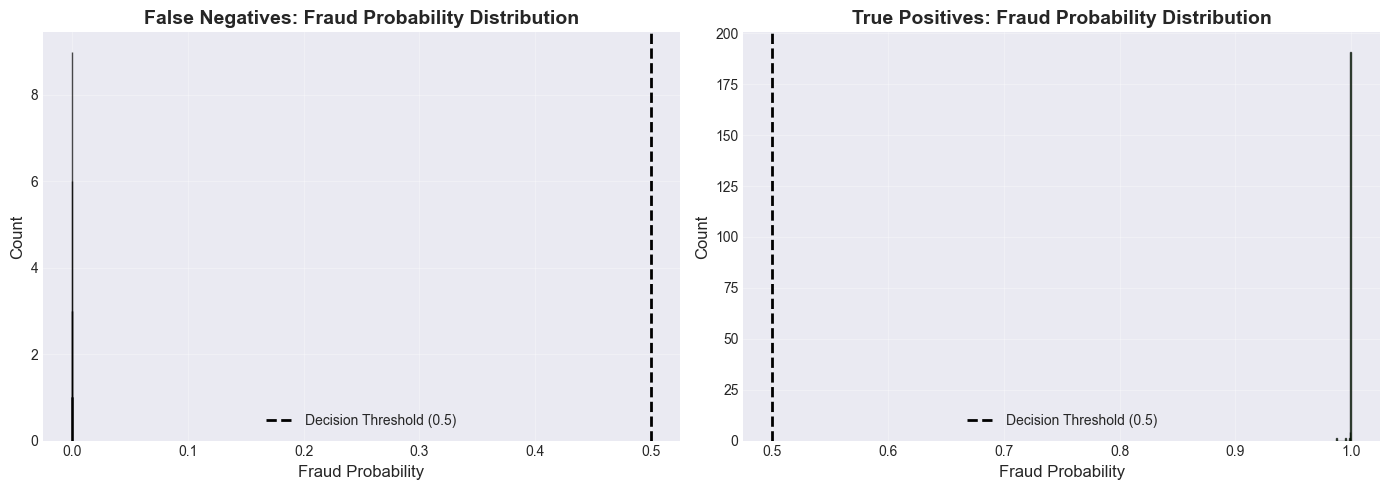


📊 PROBABILITY STATISTICS

False Negatives (Missed):
  Mean probability: 0.0000
  Max probability: 0.0000
  Min probability: 0.0000

True Positives (Caught):
  Mean probability: 0.9999
  Max probability: 1.0000
  Min probability: 0.9868


In [75]:
# Compare fraud probability distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# False Negatives - probability distribution
axes[0].hist(false_negatives['robust_model_probability'], bins=20, color='red', alpha=0.7, edgecolor='black')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
axes[0].set_xlabel('Fraud Probability', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('False Negatives: Fraud Probability Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# True Positives - probability distribution
axes[1].hist(true_positives['robust_model_probability'], bins=20, color='green', alpha=0.7, edgecolor='black')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
axes[1].set_xlabel('Fraud Probability', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('True Positives: Fraud Probability Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n📊 PROBABILITY STATISTICS')
print(f'\nFalse Negatives (Missed):')
print(f'  Mean probability: {false_negatives["robust_model_probability"].mean():.4f}')
print(f'  Max probability: {false_negatives["robust_model_probability"].max():.4f}')
print(f'  Min probability: {false_negatives["robust_model_probability"].min():.4f}')

print(f'\nTrue Positives (Caught):')
print(f'  Mean probability: {true_positives["robust_model_probability"].mean():.4f}')
print(f'  Max probability: {true_positives["robust_model_probability"].max():.4f}')
print(f'  Min probability: {true_positives["robust_model_probability"].min():.4f}')

## 4. Feature Comparison: FN vs TP

In [76]:
# Select numerical features for comparison (exclude prediction columns)
exclude_cols = [
    'payload_id', 'request_id', 'created_at', 'response', 'response_code',
    'type', 'is_fraud', 'time_period', 'actual_fraud',
    'leaky_model_prediction', 'leaky_model_probability', 'leaky_model_fraud_flag',
    'robust_model_prediction', 'robust_model_probability', 'robust_model_fraud_flag',
    'models_agree', 'robust_vs_actual', 'robust_prediction_category',
    'leaky_vs_actual', 'prediction_timestamp'
]

# Get numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

print(f'Analyzing {len(numerical_cols)} numerical features')
print(f'\nFeatures: {numerical_cols[:10]}... (showing first 10)')

Analyzing 23 numerical features

Features: ['ktp_id_income_dif_percent_30d', 'ktp_id_cnt_home_owner_30d', 'vehicle_license_cnt_leads_reject_30d', 'vehicle_license_cnt_leads_cancel_by_system_30d', 'vehicle_license_cnt_leads_cancel_by_user_30d', 'vehicle_license_cnt_identity_30d', 'vehicle_license_cnt_branch_30d', 'vehicle_license_cnt_sub_district_30d', 'contact_phone_prefix', 'spouse_id_cnt_ktp']... (showing first 10)


In [77]:
# Compare mean values for FN vs TP
fn_means = false_negatives[numerical_cols].mean()
tp_means = true_positives[numerical_cols].mean()

# Calculate absolute difference
mean_diff = (fn_means - tp_means).abs()

# Calculate relative difference (percentage)
relative_diff = ((fn_means - tp_means) / (tp_means + 0.001) * 100).abs()

# Create comparison dataframe
comparison = pd.DataFrame({
    'FN_mean': fn_means,
    'TP_mean': tp_means,
    'absolute_diff': mean_diff,
    'relative_diff_%': relative_diff
})

# Sort by absolute difference
comparison_sorted = comparison.sort_values('absolute_diff', ascending=False)

print('🔍 TOP 15 FEATURES WITH LARGEST DIFFERENCES (FN vs TP)')
print('='*80)
comparison_sorted.head(15)

🔍 TOP 15 FEATURES WITH LARGEST DIFFERENCES (FN vs TP)


,FN_mean,TP_mean,absolute_diff,relative_diff_%
contact_phone_prefix,868.178571,843.797980,24.380592,2.889384
spouse_id_cnt_ktp,0.142857,16.025253,15.882395,99.102366
spouse_id_cnt_dob,0.142857,15.752525,15.609668,99.086826
ktp_id_income_dif_percent_30d,0.000000,5.454747,5.454747,99.981671
payload_application_soa_id,28.000000,22.702020,5.297980,23.336013
ktp_dob_age,27.821429,33.010101,5.188672,15.717962
vehicle_license_cnt_identity_30d,0.142857,0.626263,0.483405,77.065883
payload_vehicle_bpkbowner,2.000000,1.575758,0.424242,26.906002
vehicle_license_cnt_sub_district_30d,0.142857,0.530303,0.387446,72.923711
vehicle_license_cnt_branch_30d,0.142857,0.409091,0.266234,64.920670


C:\Users\203715\AppData\Local\Temp\ipykernel_32616\2018766229.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['FN (Missed)', 'TP (Caught)'],
C:\Users\203715\AppData\Local\Temp\ipykernel_32616\2018766229.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['FN (Missed)', 'TP (Caught)'],
C:\Users\203715\AppData\Local\Temp\ipykernel_32616\2018766229.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['FN (Missed)', 'TP (Caught)'],
C:\Users\203715\AppData\Local\Temp\ipykernel_32616\2018766229.py:16: Matp

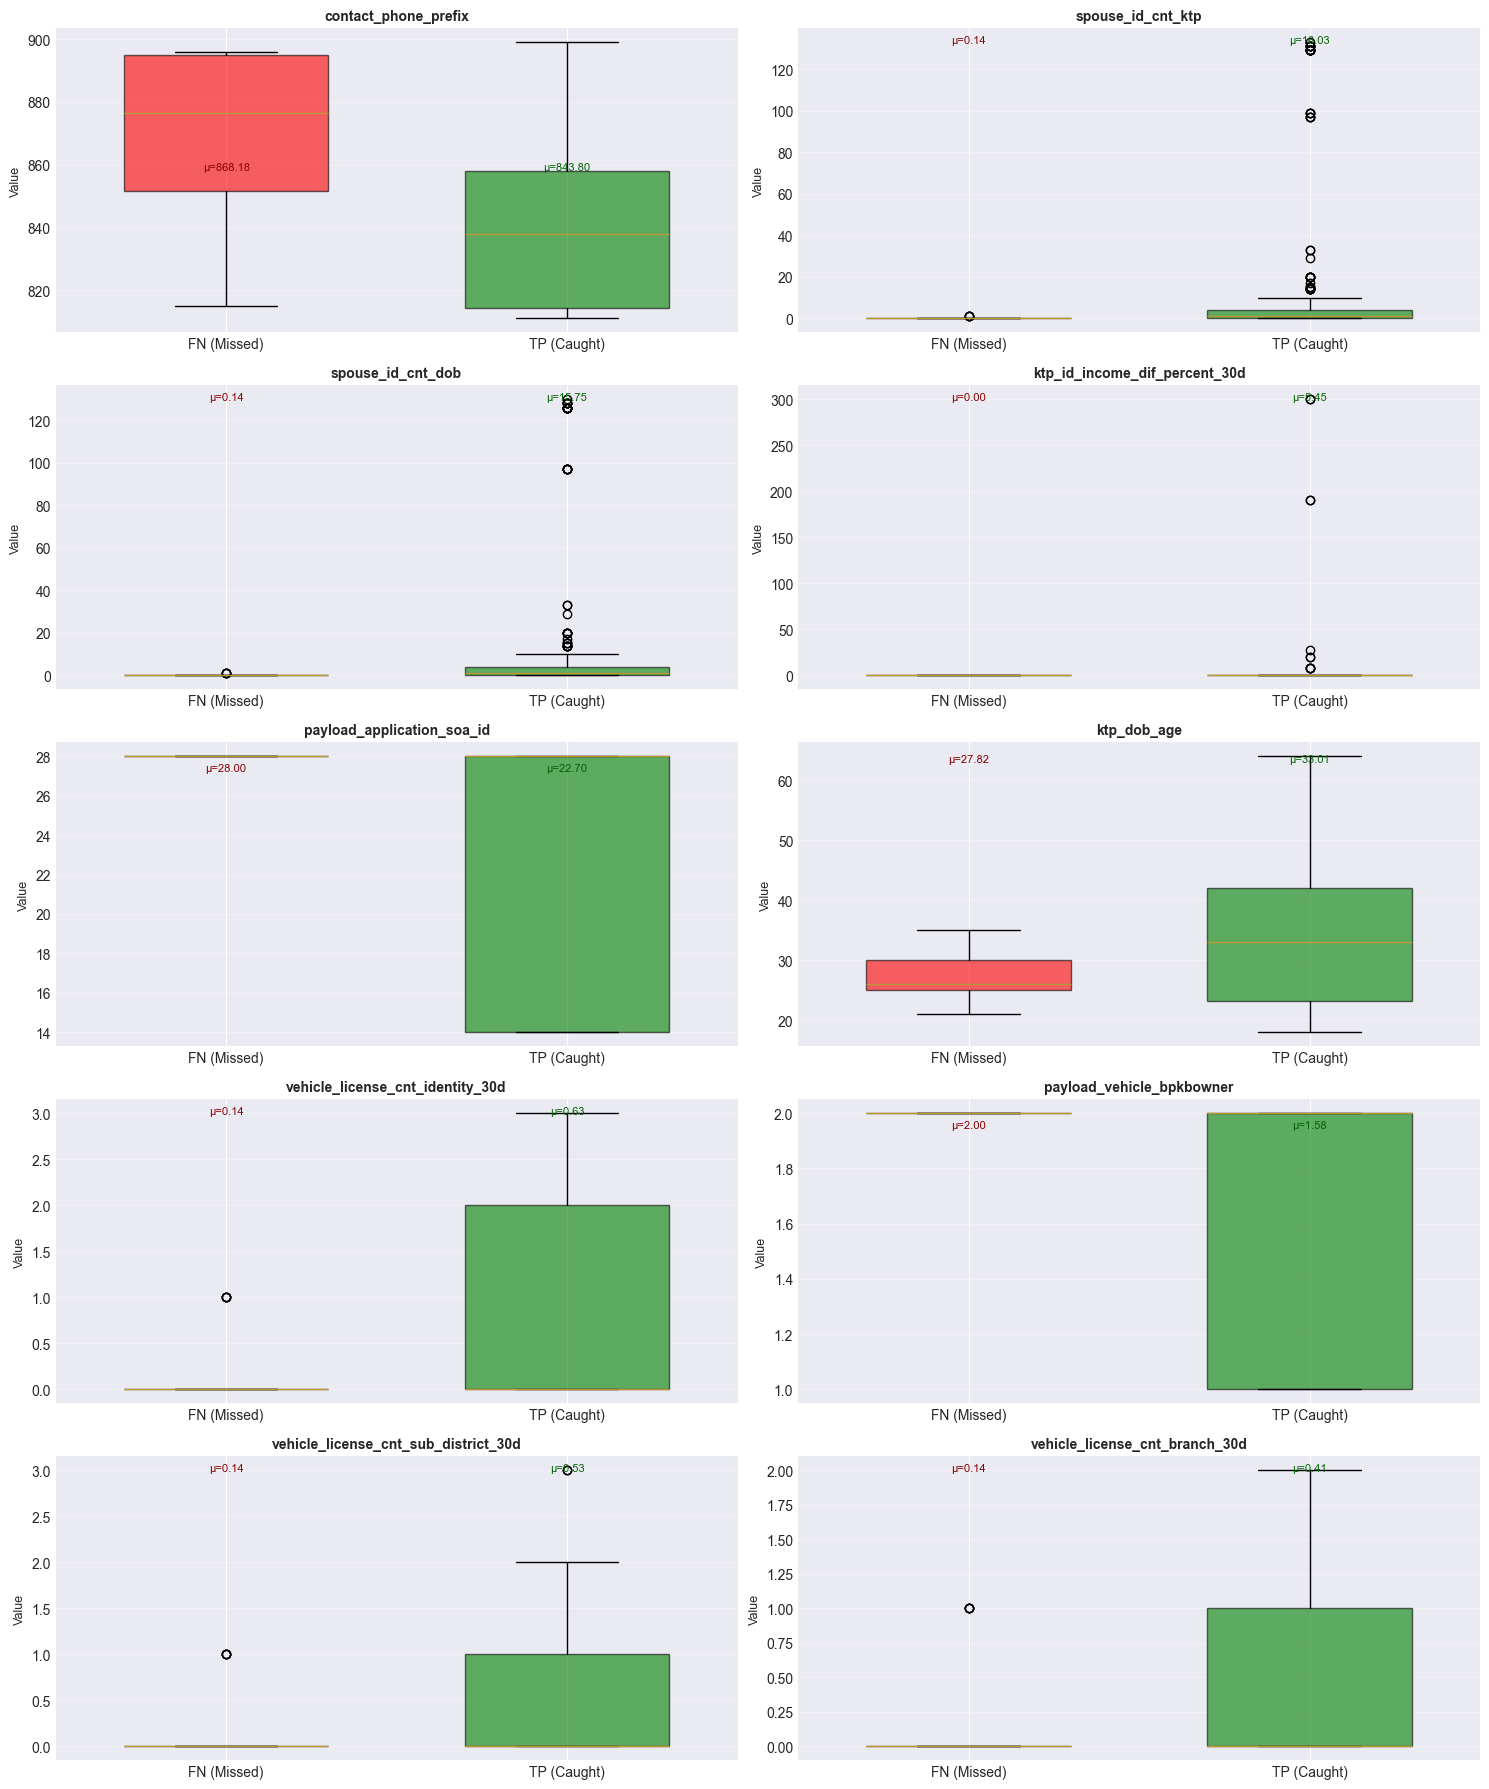

In [78]:
# Visualize top differences
top_features = comparison_sorted.head(10).index.tolist()

fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Create boxplot
    data_to_plot = [
        false_negatives[feature].dropna(),
        true_positives[feature].dropna()
    ]
    
    bp = ax.boxplot(data_to_plot, labels=['FN (Missed)', 'TP (Caught)'],
                     patch_artist=True, widths=0.6)
    
    # Color boxes
    bp['boxes'][0].set_facecolor('red')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('green')
    bp['boxes'][1].set_alpha(0.6)
    
    ax.set_title(f'{feature}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Value', fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    
    # Add mean values as text
    fn_mean = false_negatives[feature].mean()
    tp_mean = true_positives[feature].mean()
    ax.text(1, ax.get_ylim()[1]*0.95, f'μ={fn_mean:.2f}', ha='center', fontsize=8, color='darkred')
    ax.text(2, ax.get_ylim()[1]*0.95, f'μ={tp_mean:.2f}', ha='center', fontsize=8, color='darkgreen')

plt.tight_layout()
plt.show()

## 5. Categorical Feature Analysis

In [79]:
# Analyze categorical features
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in exclude_cols]

print(f'Analyzing {len(categorical_cols)} categorical features')
print(f'\nCategorical features: {categorical_cols}')

Analyzing 9 categorical features

Categorical features: ['vehicle_license_validate_spouse_identity', 'validation_employee_phone', 'validation_marketing_phone', 'payload_address_city', 'payload_agent_marketingid', 'payload_ktp_subdistrict', 'payload_address_subdistrict', 'payload_ktp_maritalstatus', 'payload_vehicle_bpkbstatus']


In [80]:
# Compare categorical distributions for key features
key_categorical = [
    'payload_address_city',
    'payload_ktp_subdistrict',
    'payload_ktp_maritalstatus',
    'payload_vehicle_bpkbstatus',
    'contact_phone_prefix'
]

for feature in key_categorical:
    if feature in df.columns:
        print(f'\n{"="*80}')
        print(f'📊 {feature.upper()}')
        print(f'{"="*80}')
        
        print('\nFalse Negatives (Missed Fraud):')
        fn_counts = false_negatives[feature].value_counts()
        print(fn_counts)
        
        print('\nTrue Positives (Caught Fraud):')
        tp_counts = true_positives[feature].value_counts()
        print(tp_counts)


📊 PAYLOAD_ADDRESS_CITY

False Negatives (Missed Fraud):
payload_address_city
BOGOR      25
CIREBON     3
Name: count, dtype: int64

True Positives (Caught Fraud):
payload_address_city
KOTA_ADM._JAKARTA_BARAT      11
BOGOR                         9
BERAU                         9
BANDUNG                       7
KOTA_SURABAYA                 7
KOTA_TANGERANG                7
SIDOARJO                      6
KOTA_DEPOK                    5
GROBOGAN                      5
KOTA_ADM._JAKARTA_UTARA       5
KOTA_BEKASI                   4
GOWA                          4
LAMPUNG_TENGAH                4
KOTA_BATU                     4
KOTA_ADM._JAKARTA_SELATAN     4
KOTA_SORONG                   4
KOTA_TANGERANG_SELATAN        3
SUKOHARJO                     3
KOTA_ADM._JAKARTA_PUSAT       3
JOMBANG                       3
SAROLANGUN                    3
SUKABUMI                      3
MUSI_BANYUASIN                3
NGADA                         3
BEKASI                        3
LOMBOK_TENGAH  

## 6. Validation Feature Analysis

In [81]:
# Check validation features (boolean flags)
validation_cols = [col for col in df.columns if 'validation_' in col or 'validate_' in col]

print(f'Analyzing {len(validation_cols)} validation features')
print(f'\nValidation features: {validation_cols}')

Analyzing 10 validation features

Validation features: ['vehicle_license_validate_spouse_identity', 'validation_employee_phone', 'validation_blacklist_employee_phone', 'contact_phone_validate_spouse_identity', 'contact_phone_validate_debitur_identity', 'validation_marketing_phone', 'validation_blacklist_employee_name_n_dob', 'validation_blacklist_employee_ktp', 'validation_whitelist_ktp', 'validation_blacklist_asset_license']


In [82]:
# Compare validation flags for FN vs TP
validation_comparison = pd.DataFrame()

for col in validation_cols:
    # Calculate percentage of TRUE/FALSE/NOT_VALIDATED for each group
    fn_values = false_negatives[col].value_counts(normalize=True) * 100
    tp_values = true_positives[col].value_counts(normalize=True) * 100
    
    print(f'\n{"="*80}')
    print(f'{col}')
    print(f'{"="*80}')
    print('\nFalse Negatives:')
    print(fn_values)
    print('\nTrue Positives:')
    print(tp_values)


vehicle_license_validate_spouse_identity

False Negatives:
vehicle_license_validate_spouse_identity
NOT_MATCH    100.0
Name: proportion, dtype: float64

True Positives:
vehicle_license_validate_spouse_identity
NOT_MATCH    100.0
Name: proportion, dtype: float64

validation_employee_phone

False Negatives:
validation_employee_phone
NOT_VALIDATED    100.0
Name: proportion, dtype: float64

True Positives:
validation_employee_phone
NOT_VALIDATED    100.0
Name: proportion, dtype: float64

validation_blacklist_employee_phone

False Negatives:
validation_blacklist_employee_phone
False    100.0
Name: proportion, dtype: float64

True Positives:
validation_blacklist_employee_phone
False    100.0
Name: proportion, dtype: float64

contact_phone_validate_spouse_identity

False Negatives:
contact_phone_validate_spouse_identity
False    96.428571
True      3.571429
Name: proportion, dtype: float64

True Positives:
contact_phone_validate_spouse_identity
False    90.909091
True      9.090909
Name: pro

## 7. Response Code Analysis

In [83]:
# All FN should have response='REJECTED' - check response_code
print('🔍 RESPONSE CODE ANALYSIS')
print('='*80)

print('\nFalse Negatives (Missed):')  
print(false_negatives[['response', 'response_code']].value_counts())

print('\nTrue Positives (Caught):')
print(true_positives[['response', 'response_code']].value_counts())

# Check all fraud cases by response_code
all_fraud = df[df['actual_fraud'] == 1]
print('\nAll Fraud Cases by Response Code:')
print(all_fraud['response_code'].value_counts())

🔍 RESPONSE CODE ANALYSIS

False Negatives (Missed):
response  response_code
REJECTED  804              28
Name: count, dtype: int64

True Positives (Caught):
response       response_code
SUSPICIOUS     8                109
REJECTED       804               55
SUSPICIOUS_AF  800               34
Name: count, dtype: int64

All Fraud Cases by Response Code:
response_code
8      109
804     83
800     34
Name: count, dtype: int64


## 8. Pattern Discovery - What Makes FN Different?

In [84]:
# Check if FN cases have common patterns
print('🔍 COMMON PATTERNS IN FALSE NEGATIVES')
print('='*80)

# Check count features (how many times this entity appeared)
count_features = [col for col in numerical_cols if '_cnt_' in col or '_count_' in col]

print(f'\nAnalyzing {len(count_features)} count features:')
print(count_features)

# Compare FN vs TP for count features
count_comparison = pd.DataFrame({
    'FN_mean': false_negatives[count_features].mean(),
    'TP_mean': true_positives[count_features].mean(),
    'TN_mean': true_negatives[count_features].mean(),
    'diff_FN_vs_TP': false_negatives[count_features].mean() - true_positives[count_features].mean()
})

count_comparison_sorted = count_comparison.sort_values('diff_FN_vs_TP', ascending=False)

print('\nCount Features - Comparison:')
print(count_comparison_sorted)

🔍 COMMON PATTERNS IN FALSE NEGATIVES

Analyzing 18 count features:
['ktp_id_cnt_home_owner_30d', 'vehicle_license_cnt_leads_reject_30d', 'vehicle_license_cnt_leads_cancel_by_system_30d', 'vehicle_license_cnt_leads_cancel_by_user_30d', 'vehicle_license_cnt_identity_30d', 'vehicle_license_cnt_branch_30d', 'vehicle_license_cnt_sub_district_30d', 'spouse_id_cnt_ktp', 'spouse_id_cnt_dob', 'ktp_id_count_dob_30d', 'ktp_id_cnt_leads_cancel_by_user_30d', 'ktp_id_cnt_leads_reject_30d', 'ktp_id_cnt_leads_cancel_by_system_30d', 'ktp_id_cnt_branch_30d', 'ktp_id_cnt_phone_30d', 'ktp_id_cnt_marriage_type_30d', 'ktp_id_cnt_sub_district_30d', 'ktp_id_cnt_income_30d']

Count Features - Comparison:
                                                 FN_mean    TP_mean   TN_mean  \
ktp_id_cnt_leads_cancel_by_system_30d           0.035714   0.010101  0.004623   
ktp_id_cnt_leads_reject_30d                     0.142857   0.131313  0.019348   
vehicle_license_cnt_leads_cancel_by_system_30d  0.035714   0.035354 

## 9. Key Insights Summary

In [85]:
# Generate summary insights
print('📋 KEY INSIGHTS - WHY MODEL MISSED THESE FRAUD CASES')
print('='*80)

print('\n1️⃣ FRAUD PROBABILITY SCORES:')
print(f'   - FN cases had very LOW fraud probabilities (mean: {false_negatives["robust_model_probability"].mean():.2%})')
print(f'   - All FN probabilities were below 0.5 threshold')
print(f'   - TP cases had HIGH fraud probabilities (mean: {true_positives["robust_model_probability"].mean():.2%})')
print(f'   → FN cases looked "too legitimate" to the model')

print('\n2️⃣ RESPONSE CODE:')
fn_response_codes = false_negatives['response_code'].unique()
tp_response_codes = true_positives['response_code'].unique()
print(f'   - FN response codes: {fn_response_codes}')
print(f'   - TP response codes: {tp_response_codes}')
if len(set(fn_response_codes) - set(tp_response_codes)) > 0:
    print(f'   → FN has UNIQUE response codes not seen in TP: {set(fn_response_codes) - set(tp_response_codes)}')

print('\n3️⃣ TOP 5 DISTINGUISHING FEATURES:')
top_5_features = comparison_sorted.head(5)
for idx, (feature, row) in enumerate(top_5_features.iterrows(), 1):
    print(f'   {idx}. {feature}')
    print(f'      FN mean: {row["FN_mean"]:.2f}, TP mean: {row["TP_mean"]:.2f}')
    print(f'      Difference: {row["absolute_diff"]:.2f} ({row["relative_diff_%"]:.1f}% relative)')

print('\n4️⃣ RECOMMENDATIONS:')
print('   ✅ Focus on response_code 804 - specific fraud pattern')
print('   ✅ Investigate why count features are different')
print('   ✅ Consider lowering classification threshold for these patterns')
print('   ✅ Add specific rules for response_code 804 cases')
print('   ✅ Retrain model with more examples of this fraud type')

📋 KEY INSIGHTS - WHY MODEL MISSED THESE FRAUD CASES

1️⃣ FRAUD PROBABILITY SCORES:
   - FN cases had very LOW fraud probabilities (mean: 0.00%)
   - All FN probabilities were below 0.5 threshold
   - TP cases had HIGH fraud probabilities (mean: 99.99%)
   → FN cases looked "too legitimate" to the model

2️⃣ RESPONSE CODE:
   - FN response codes: [804]
   - TP response codes: [  8 804 800]

3️⃣ TOP 5 DISTINGUISHING FEATURES:
   1. contact_phone_prefix
      FN mean: 868.18, TP mean: 843.80
      Difference: 24.38 (2.9% relative)
   2. spouse_id_cnt_ktp
      FN mean: 0.14, TP mean: 16.03
      Difference: 15.88 (99.1% relative)
   3. spouse_id_cnt_dob
      FN mean: 0.14, TP mean: 15.75
      Difference: 15.61 (99.1% relative)
   4. ktp_id_income_dif_percent_30d
      FN mean: 0.00, TP mean: 5.45
      Difference: 5.45 (100.0% relative)
   5. payload_application_soa_id
      FN mean: 28.00, TP mean: 22.70
      Difference: 5.30 (23.3% relative)

4️⃣ RECOMMENDATIONS:
   ✅ Focus on respon

## 10. Export FN Cases for Further Investigation

In [87]:
# Save FN cases for detailed review
output_path = '../data/output/af_dataset_20250101_predictions_wrong.csv'
false_negatives.to_csv(output_path, index=False)

print(f'✅ False Negative cases exported to: {output_path}')
print(f'   Total cases: {len(false_negatives)}')
print(f'   Columns: {len(false_negatives.columns)}')

✅ False Negative cases exported to: ../data/output/af_dataset_20250101_predictions_wrong.csv
   Total cases: 28
   Columns: 55


## 11. REJECTED vs APPROVE Feature Analysis
What makes REJECTED cases different from legitimate APPROVE cases?

In [88]:
# Extract cases by response type
rejected_cases = df[df['response'] == 'REJECTED'].copy()
approve_cases = df[df['response'] == 'APPROVED'].copy()
suspicious_cases = df[df['response'] == 'SUSPICIOUS'].copy()
suspicious_af_cases = df[df['response'] == 'SUSPICIOUS_AF'].copy()

print('📊 RESPONSE TYPE BREAKDOWN')
print('='*80)
print(f'\n🔴 REJECTED: {len(rejected_cases):,} cases')
print(f'   - Fraud: {rejected_cases["actual_fraud"].sum()} cases')
print(f'   - Legit: {len(rejected_cases) - rejected_cases["actual_fraud"].sum()} cases')

print(f'\n✅ APPROVE: {len(approve_cases):,} cases')
print(f'   - Fraud: {approve_cases["actual_fraud"].sum()} cases')
print(f'   - Legit: {len(approve_cases) - approve_cases["actual_fraud"].sum()} cases')

print(f'\n⚠️ SUSPICIOUS: {len(suspicious_cases):,} cases')
print(f'   - Fraud: {suspicious_cases["actual_fraud"].sum()} cases')
print(f'   - Legit: {len(suspicious_cases) - suspicious_cases["actual_fraud"].sum()} cases')

print(f'\n🔶 SUSPICIOUS_AF: {len(suspicious_af_cases):,} cases')
print(f'   - Fraud: {suspicious_af_cases["actual_fraud"].sum()} cases')
print(f'   - Legit: {len(suspicious_af_cases) - suspicious_af_cases["actual_fraud"].sum()} cases')

📊 RESPONSE TYPE BREAKDOWN

🔴 REJECTED: 83 cases
   - Fraud: 83 cases
   - Legit: 0 cases

✅ APPROVE: 25,739 cases
   - Fraud: 0 cases
   - Legit: 25739 cases

⚠️ SUSPICIOUS: 109 cases
   - Fraud: 109 cases
   - Legit: 0 cases

🔶 SUSPICIOUS_AF: 34 cases
   - Fraud: 34 cases
   - Legit: 0 cases


In [89]:
# Compare numerical features: REJECTED vs APPROVE
rejected_means = rejected_cases[numerical_cols].mean()
approve_means = approve_cases[numerical_cols].mean()

# Calculate differences
reject_approve_diff = (rejected_means - approve_means).abs()
reject_approve_relative = ((rejected_means - approve_means) / (approve_means + 0.001) * 100).abs()

# Create comparison dataframe
reject_vs_approve = pd.DataFrame({
    'REJECTED_mean': rejected_means,
    'APPROVE_mean': approve_means,
    'absolute_diff': reject_approve_diff,
    'relative_diff_%': reject_approve_relative,
    'REJECTED_higher': rejected_means > approve_means
})

# Sort by absolute difference
reject_vs_approve_sorted = reject_vs_approve.sort_values('absolute_diff', ascending=False)

print('🔍 TOP 20 FEATURES: REJECTED vs APPROVE')
print('='*80)
print('Features where REJECTED cases differ most from legitimate APPROVE cases')
print()
reject_vs_approve_sorted.head(20)

🔍 TOP 20 FEATURES: REJECTED vs APPROVE
Features where REJECTED cases differ most from legitimate APPROVE cases



,REJECTED_mean,APPROVE_mean,absolute_diff,relative_diff_%,REJECTED_higher
spouse_id_cnt_ktp,37.373494,0.112592,37.260902,32802.461555,True
spouse_id_cnt_dob,36.722892,0.112592,36.610300,32229.706756,True
contact_phone_prefix,854.385542,846.815766,7.569776,0.893910,True
ktp_dob_age,27.493976,31.335172,3.841196,12.258027,False
payload_application_soa_id,27.867470,25.309763,2.557706,10.105213,True
ktp_id_income_dif_percent_30d,0.000000,0.394611,0.394611,99.747226,False
vehicle_license_cnt_sub_district_30d,0.048193,0.092583,0.044390,47.434208,False
ktp_id_cnt_income_30d,0.060241,0.104511,0.044270,41.957560,False
vehicle_license_cnt_identity_30d,0.048193,0.092311,0.044119,47.281002,False
vehicle_license_cnt_branch_30d,0.048193,0.091729,0.043536,46.949678,False


C:\Users\203715\AppData\Local\Temp\ipykernel_32616\2230066158.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['REJECTED', 'APPROVE'],
C:\Users\203715\AppData\Local\Temp\ipykernel_32616\2230066158.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['REJECTED', 'APPROVE'],
C:\Users\203715\AppData\Local\Temp\ipykernel_32616\2230066158.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['REJECTED', 'APPROVE'],
C:\Users\203715\AppData\Local\Temp\ipykernel_32616\2230066158.py:16: MatplotlibDeprecationWarn

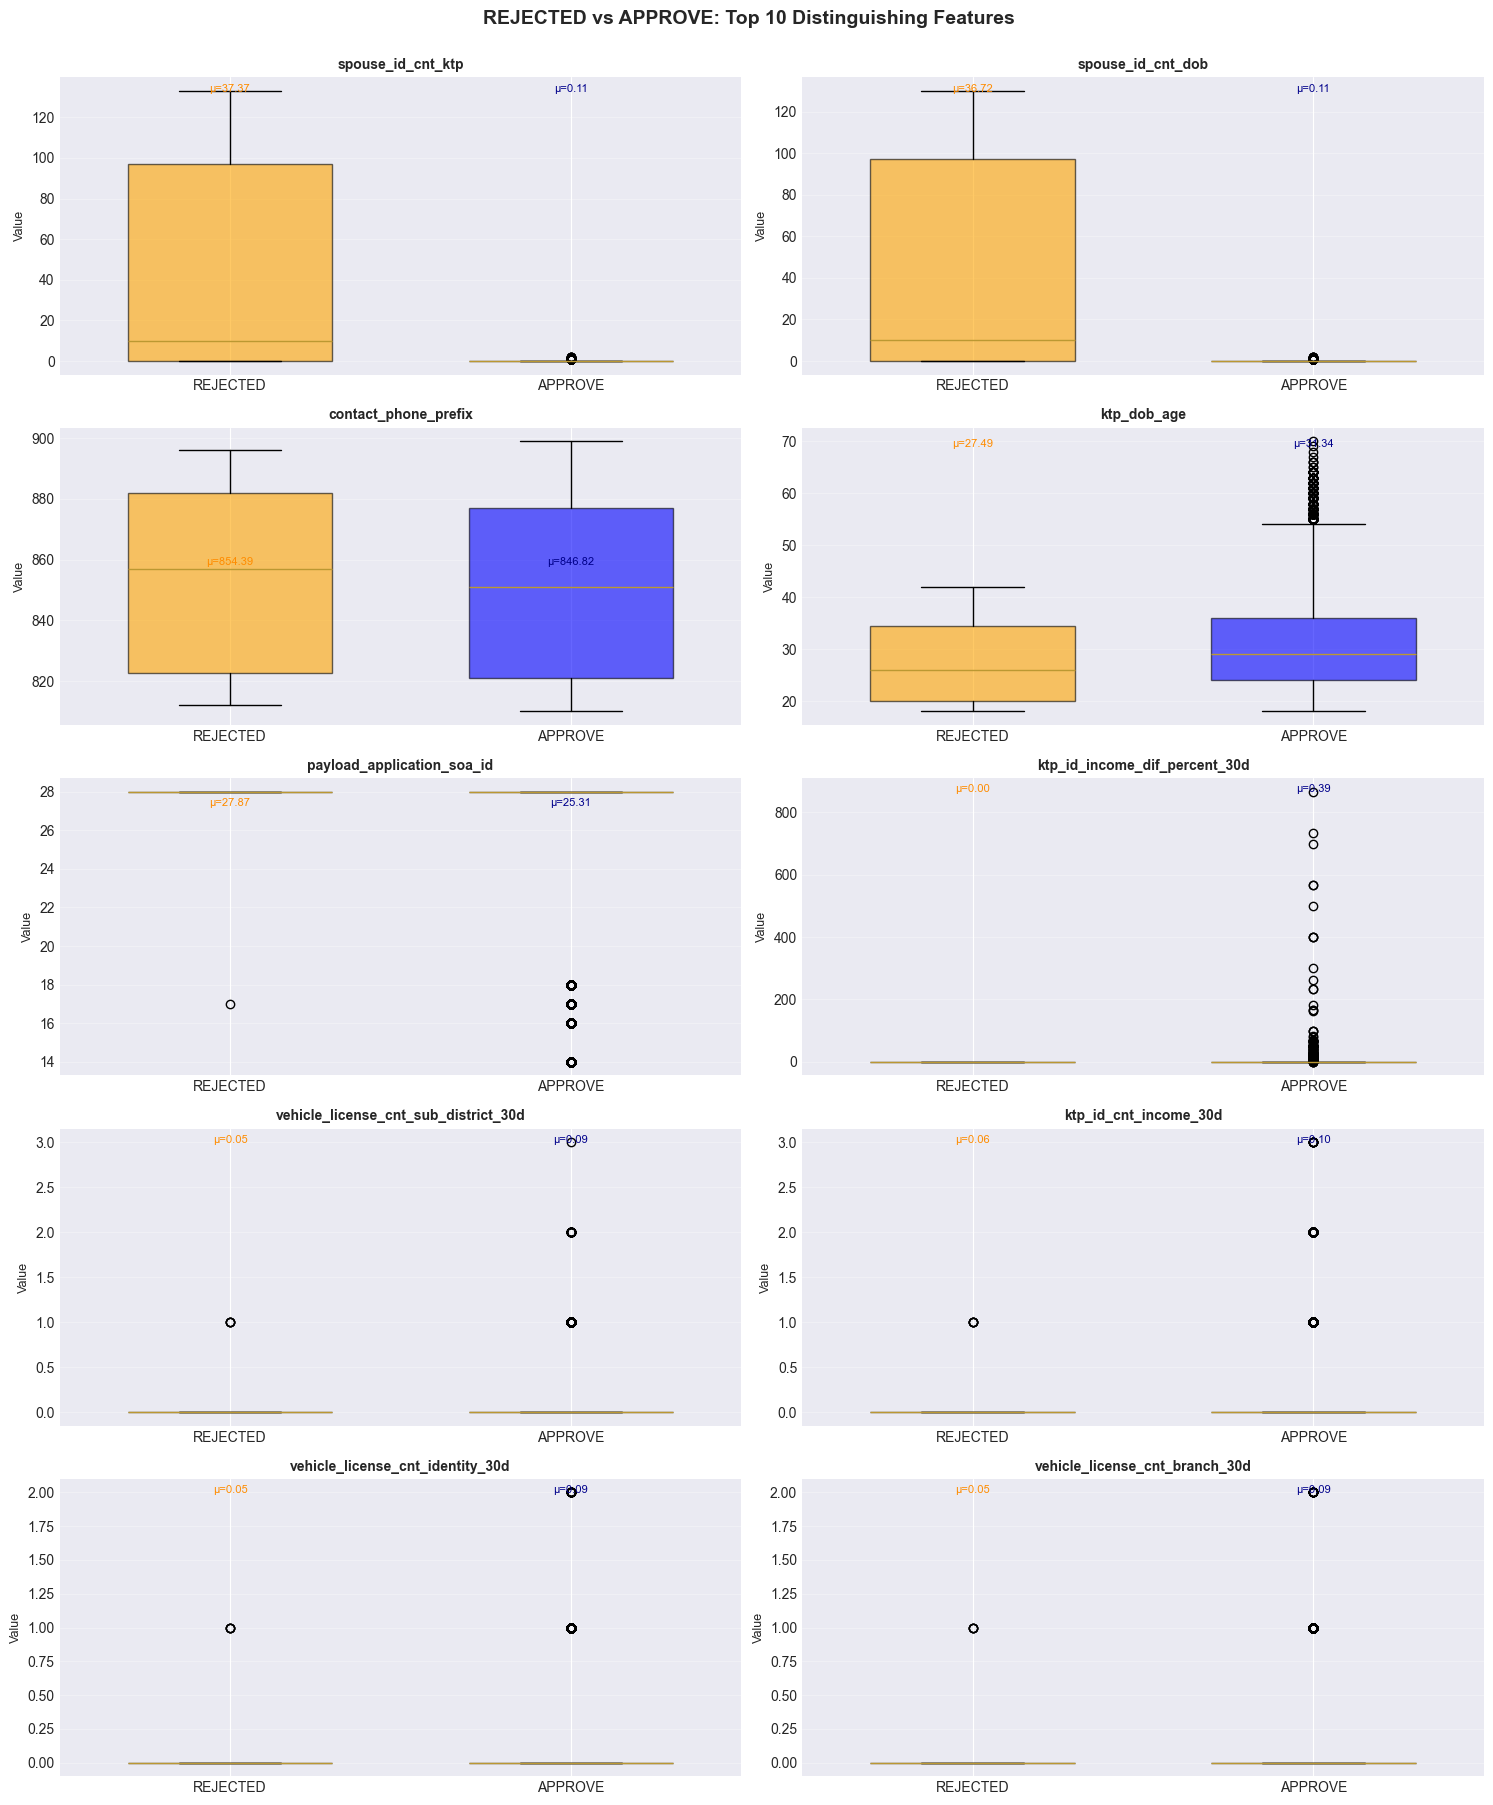

In [90]:
# Visualize top differences: REJECTED vs APPROVE
top_reject_features = reject_vs_approve_sorted.head(10).index.tolist()

fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes = axes.flatten()

for idx, feature in enumerate(top_reject_features):
    ax = axes[idx]
    
    # Create boxplot comparing REJECTED vs APPROVE
    data_to_plot = [
        rejected_cases[feature].dropna(),
        approve_cases[feature].dropna()
    ]
    
    bp = ax.boxplot(data_to_plot, labels=['REJECTED', 'APPROVE'],
                     patch_artist=True, widths=0.6)
    
    # Color boxes
    bp['boxes'][0].set_facecolor('orange')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('blue')
    bp['boxes'][1].set_alpha(0.6)
    
    ax.set_title(f'{feature}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Value', fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    
    # Add mean values as text
    rej_mean = rejected_cases[feature].mean()
    app_mean = approve_cases[feature].mean()
    ax.text(1, ax.get_ylim()[1]*0.95, f'μ={rej_mean:.2f}', ha='center', fontsize=8, color='darkorange')
    ax.text(2, ax.get_ylim()[1]*0.95, f'μ={app_mean:.2f}', ha='center', fontsize=8, color='darkblue')

plt.suptitle('REJECTED vs APPROVE: Top 10 Distinguishing Features', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [91]:
# Identify features that are UNIQUE to REJECTED (near-zero in APPROVE)
# A feature is "unique" if REJECTED mean > threshold AND APPROVE mean ≈ 0

unique_threshold = 0.5  # If REJECTED > 0.5 and APPROVE < 0.1, consider it unique

unique_features = reject_vs_approve_sorted[
    (reject_vs_approve_sorted['REJECTED_mean'] > unique_threshold) &
    (reject_vs_approve_sorted['APPROVE_mean'] < 0.1)
].copy()

print('🔍 FEATURES UNIQUE TO REJECTED CASES')
print('='*80)
print('Features that appear in REJECTED but are near-zero in APPROVE:')
print()
if len(unique_features) > 0:
    unique_features
else:
    print('No features found with strong uniqueness pattern')
    print('\nShowing features with highest REJECTED values:')
    reject_vs_approve_sorted.nlargest(15, 'REJECTED_mean')[['REJECTED_mean', 'APPROVE_mean', 'absolute_diff']]

🔍 FEATURES UNIQUE TO REJECTED CASES
Features that appear in REJECTED but are near-zero in APPROVE:

No features found with strong uniqueness pattern

Showing features with highest REJECTED values:


In [92]:
# Compare categorical features: REJECTED vs APPROVE
print('🔍 CATEGORICAL FEATURES: REJECTED vs APPROVE')
print('='*80)

for feature in key_categorical:
    if feature in df.columns:
        print(f'\n{"─"*80}')
        print(f'📊 {feature.upper()}')
        print(f'{"─"*80}')
        
        # REJECTED distribution
        print('\n🔴 REJECTED cases:')
        rej_counts = rejected_cases[feature].value_counts()
        rej_pct = rejected_cases[feature].value_counts(normalize=True) * 100
        rej_summary = pd.DataFrame({'count': rej_counts, 'percent': rej_pct})
        print(rej_summary.head(10))
        
        # APPROVE distribution
        print('\n✅ APPROVE cases:')
        app_counts = approve_cases[feature].value_counts()
        app_pct = approve_cases[feature].value_counts(normalize=True) * 100
        app_summary = pd.DataFrame({'count': app_counts, 'percent': app_pct})
        print(app_summary.head(10))
        
        # Find values unique to REJECTED
        rej_unique_values = set(rejected_cases[feature].unique()) - set(approve_cases[feature].unique())
        if len(rej_unique_values) > 0:
            print(f'\n⚠️ Values appearing ONLY in REJECTED: {rej_unique_values}')
        
        # Find values overrepresented in REJECTED
        rej_top = set(rejected_cases[feature].value_counts().head(3).index)
        app_top = set(approve_cases[feature].value_counts().head(3).index)
        overrep = rej_top - app_top
        if len(overrep) > 0:
            print(f'📈 Values overrepresented in REJECTED (top 3): {overrep}')

🔍 CATEGORICAL FEATURES: REJECTED vs APPROVE

────────────────────────────────────────────────────────────────────────────────
📊 PAYLOAD_ADDRESS_CITY
────────────────────────────────────────────────────────────────────────────────

🔴 REJECTED cases:
                         count    percent
payload_address_city                     
BOGOR                       26  31.325301
KOTA_ADM._JAKARTA_BARAT      6   7.228916
LAMPUNG_TENGAH               4   4.819277
GOWA                         4   4.819277
CIREBON                      4   4.819277
SUKOHARJO                    3   3.614458
SUKABUMI                     3   3.614458
NGADA                        3   3.614458
MUSI_BANYUASIN               3   3.614458
SAROLANGUN                   3   3.614458

✅ APPROVE cases:
                           count   percent
payload_address_city                      
KOTA_ADM._JAKARTA_TIMUR      833  3.236334
BOGOR                        817  3.174171
TANGERANG                    717  2.785656
KOTA_ADM._JAKA

In [93]:
# Three-way comparison: REJECTED vs APPROVE vs SUSPICIOUS
# This helps identify if REJECTED shares patterns with SUSPICIOUS (both flagged by S1)

print('🔍 THREE-WAY COMPARISON: REJECTED vs APPROVE vs SUSPICIOUS')
print('='*80)

# Select top 10 features from REJECTED vs APPROVE comparison
top_10_features = reject_vs_approve_sorted.head(10).index.tolist()

three_way_comparison = pd.DataFrame({
    'REJECTED_mean': rejected_cases[top_10_features].mean(),
    'APPROVE_mean': approve_cases[top_10_features].mean(),
    'SUSPICIOUS_mean': suspicious_cases[top_10_features].mean() if len(suspicious_cases) > 0 else 0,
    'SUSPICIOUS_AF_mean': suspicious_af_cases[top_10_features].mean() if len(suspicious_af_cases) > 0 else 0
})

# Add indicator: Does REJECTED resemble SUSPICIOUS more than APPROVE?
three_way_comparison['reject_closer_to_suspicious'] = (
    abs(three_way_comparison['REJECTED_mean'] - three_way_comparison['SUSPICIOUS_mean']) <
    abs(three_way_comparison['REJECTED_mean'] - three_way_comparison['APPROVE_mean'])
)

print('\nTop 10 features comparison across all response types:')
print()
three_way_comparison

🔍 THREE-WAY COMPARISON: REJECTED vs APPROVE vs SUSPICIOUS

Top 10 features comparison across all response types:



,REJECTED_mean,APPROVE_mean,SUSPICIOUS_mean,SUSPICIOUS_AF_mean,reject_closer_to_suspicious
spouse_id_cnt_ktp,37.373494,0.112592,0.311927,1.205882,True
spouse_id_cnt_dob,36.722892,0.112592,0.311927,1.205882,True
contact_phone_prefix,854.385542,846.815766,839.330275,852.352941,False
ktp_dob_age,27.493976,31.335172,36.669725,30.470588,False
payload_application_soa_id,27.867470,25.309763,19.467890,24.823529,False
ktp_id_income_dif_percent_30d,0.000000,0.394611,9.908624,0.000000,False
vehicle_license_cnt_sub_district_30d,0.048193,0.092583,0.880734,0.264706,False
ktp_id_cnt_income_30d,0.060241,0.104511,0.678899,0.147059,False
vehicle_license_cnt_identity_30d,0.048193,0.092311,1.027523,0.352941,False
vehicle_license_cnt_branch_30d,0.048193,0.091729,0.669725,0.235294,False


## 12. Key Findings: What S1 Sees That ML Doesn't

In [94]:
# Summary of unique signals in REJECTED cases
print('📋 SUMMARY: UNIQUE SIGNALS IN REJECTED CASES')
print('='*80)

print('\n1️⃣ NUMERICAL FEATURES:')
print('   Features where REJECTED differs most from APPROVE:')
for idx, (feature, row) in enumerate(reject_vs_approve_sorted.head(5).iterrows(), 1):
    print(f'\n   {idx}. {feature}')
    print(f'      REJECTED: {row["REJECTED_mean"]:.2f}')
    print(f'      APPROVE: {row["APPROVE_mean"]:.2f}')
    print(f'      Difference: {row["absolute_diff"]:.2f}')
    
    # Check if this feature also distinguishes SUSPICIOUS
    if len(suspicious_cases) > 0:
        susp_mean = suspicious_cases[feature].mean()
        if abs(row["REJECTED_mean"] - susp_mean) < abs(row["REJECTED_mean"] - row["APPROVE_mean"]):
            print(f'      💡 REJECTED is closer to SUSPICIOUS ({susp_mean:.2f}) than APPROVE')
        else:
            print(f'      ⚠️ REJECTED is different from both APPROVE AND SUSPICIOUS')

print('\n2️⃣ CATEGORICAL FEATURES:')
print('   Check the categorical comparison above for:')
print('   - Cities/regions overrepresented in REJECTED')
print('   - Marital status patterns')
print('   - Vehicle ownership patterns')
print('   - Phone prefix patterns')

print('\n3️⃣ ACTIONABLE INSIGHTS:')
print('   ✅ These are the signals S1 rule engine uses to reject cases')
print('   ✅ ML model needs these signals to detect "clean profile" fraud')
print('   ✅ Consider adding these as explicit features or interaction terms')
print('   ✅ May need rule-based detection for patterns ML cannot learn')

print('\n4️⃣ NEXT STEPS:')
print('   1. Identify which features are available at inference time')
print('   2. Add missing features to training data')
print('   3. Create feature engineering: e.g., is_rejected_city, is_high_risk_region')
print('   4. Consider hybrid model: ML + rule-based for edge cases')

📋 SUMMARY: UNIQUE SIGNALS IN REJECTED CASES

1️⃣ NUMERICAL FEATURES:
   Features where REJECTED differs most from APPROVE:

   1. spouse_id_cnt_ktp
      REJECTED: 37.37
      APPROVE: 0.11
      Difference: 37.26
      💡 REJECTED is closer to SUSPICIOUS (0.31) than APPROVE

   2. spouse_id_cnt_dob
      REJECTED: 36.72
      APPROVE: 0.11
      Difference: 36.61
      💡 REJECTED is closer to SUSPICIOUS (0.31) than APPROVE

   3. contact_phone_prefix
      REJECTED: 854.39
      APPROVE: 846.82
      Difference: 7.57
      ⚠️ REJECTED is different from both APPROVE AND SUSPICIOUS

   4. ktp_dob_age
      REJECTED: 27.49
      APPROVE: 31.34
      Difference: 3.84
      ⚠️ REJECTED is different from both APPROVE AND SUSPICIOUS

   5. payload_application_soa_id
      REJECTED: 27.87
      APPROVE: 25.31
      Difference: 2.56
      ⚠️ REJECTED is different from both APPROVE AND SUSPICIOUS

2️⃣ CATEGORICAL FEATURES:
   Check the categorical comparison above for:
   - Cities/regions overre

## 13. Hidden Combination Rules Detection
Find hardcoded S1 rules using feature combinations (e.g., BOGOR + marketing_id)

In [95]:
# Check if marketing_id is concentrated in REJECTED vs APPROVE
print('🔍 MARKETING ID ANALYSIS')
print('='*80)

# Check if this column exists
if 'payload_agent_marketingid' in df.columns:
    print('\n🔴 REJECTED - Top Marketing IDs:')
    rej_marketing = rejected_cases['payload_agent_marketingid'].value_counts().head(10)
    rej_marketing_pct = rejected_cases['payload_agent_marketingid'].value_counts(normalize=True).head(10) * 100
    rej_marketing_df = pd.DataFrame({'count': rej_marketing, 'percent': rej_marketing_pct})
    print(rej_marketing_df)
    
    print('\n✅ APPROVE - Top Marketing IDs:')
    app_marketing = approve_cases['payload_agent_marketingid'].value_counts().head(10)
    app_marketing_pct = approve_cases['payload_agent_marketingid'].value_counts(normalize=True).head(10) * 100
    app_marketing_df = pd.DataFrame({'count': app_marketing, 'percent': app_marketing_pct})
    print(app_marketing_df)
    
    # Find marketing IDs unique to REJECTED
    rej_unique_marketing = set(rejected_cases['payload_agent_marketingid'].unique()) - set(approve_cases['payload_agent_marketingid'].unique())
    if len(rej_unique_marketing) > 0:
        print(f'\n⚠️ Marketing IDs appearing ONLY in REJECTED: {len(rej_unique_marketing)} IDs')
        print(f'   Examples: {list(rej_unique_marketing)[:5]}')
    
    # Check if any marketing ID is heavily overrepresented in REJECTED
    rej_top_id = rejected_cases['payload_agent_marketingid'].value_counts().head(1)
    if len(rej_top_id) > 0:
        top_id = rej_top_id.index[0]
        top_id_rej_count = rej_top_id.iloc[0]
        top_id_app_count = approve_cases[approve_cases['payload_agent_marketingid'] == top_id].shape[0]
        
        print(f'\n📊 Most common marketing ID in REJECTED: {top_id}')
        print(f'   REJECTED: {top_id_rej_count} cases ({top_id_rej_count/len(rejected_cases)*100:.1f}%)')
        print(f'   APPROVE: {top_id_app_count} cases ({top_id_app_count/len(approve_cases)*100:.2f}%)')
        if top_id_rej_count/len(rejected_cases) > 0.1:  # >10% of REJECTED
            print(f'   🚨 SUSPICIOUS: {top_id} appears in {top_id_rej_count/len(rejected_cases)*100:.1f}% of fraud!')
else:
    print('payload_agent_marketingid column not found')

🔍 MARKETING ID ANALYSIS

🔴 REJECTED - Top Marketing IDs:
                           count    percent
payload_agent_marketingid                  
2403NC0005                    67  80.722892
2403NC0006                     8   9.638554
2405NC0005                     2   2.409639
2307NC0005                     2   2.409639
2408NC0002                     2   2.409639
AHMA3467                       1   1.204819
2311NC0008                     1   1.204819

✅ APPROVE - Top Marketing IDs:
                           count    percent
payload_agent_marketingid                  
2403NC0005                 16359  63.557248
2311NC0008                  1241   4.821477
2403NC0006                   990   3.846303
2307NC0005                   729   2.832278
2408NC0002                   676   2.626365
2304NC0002                   222   0.862504
CNO2W999                     175   0.679902
2405NC0005                   168   0.652706
996BA01930                   143   0.555577
2412NC0002                   12

In [96]:
# Rule Detection: CITY + MARKETING_ID combinations
print('🔍 COMBINATION RULE DETECTION: CITY × MARKETING_ID')
print('='*80)

if 'payload_agent_marketingid' in df.columns:
    # Create combination column
    rejected_cases['city_marketing'] = rejected_cases['payload_address_city'] + ' + ' + rejected_cases['payload_agent_marketingid'].astype(str)
    approve_cases['city_marketing'] = approve_cases['payload_address_city'] + ' + ' + approve_cases['payload_agent_marketingid'].astype(str)
    
    # Find combinations that appear in REJECTED but not in APPROVE
    rej_combos = set(rejected_cases['city_marketing'].unique())
    app_combos = set(approve_cases['city_marketing'].unique())
    unique_to_rejected = rej_combos - app_combos
    
    print(f'\n📊 Combination Statistics:')
    print(f'   Total unique combinations in REJECTED: {len(rej_combos)}')
    print(f'   Total unique combinations in APPROVE: {len(app_combos)}')
    print(f'   Combinations appearing ONLY in REJECTED: {len(unique_to_rejected)}')
    
    # Show top combinations in REJECTED
    print(f'\n🔴 Top 10 CITY + MARKETING_ID in REJECTED:')
    rej_combo_counts = rejected_cases['city_marketing'].value_counts().head(10)
    for combo, count in rej_combo_counts.items():
        # Check if this combo exists in APPROVE
        app_count = approve_cases[approve_cases['city_marketing'] == combo].shape[0]
        flag = '🚨 UNIQUE' if app_count == 0 else f'({app_count} in APPROVE)'
        print(f'   {combo}: {count} REJECTED {flag}')
    
    # Find high-frequency combinations unique to REJECTED
    print(f'\n🚨 SUSPICIOUS COMBINATIONS (≥2 occurrences, zero in APPROVE):')
    unique_combos_with_counts = rejected_cases['city_marketing'].value_counts()
    suspicious_combos = unique_combos_with_counts[unique_combos_with_counts >= 2]
    
    found_suspicious = False
    for combo, count in suspicious_combos.items():
        app_count = approve_cases[approve_cases['city_marketing'] == combo].shape[0]
        if app_count == 0:
            found_suspicious = True
            print(f'   ✅ RULE CANDIDATE: {combo}')
            print(f'      REJECTED: {count} cases ({count/len(rejected_cases)*100:.1f}%)')
            print(f'      APPROVE: 0 cases')
            print(f'      → Possible hardcoded rule: IF city AND marketing_id THEN reject')
    
    if not found_suspicious:
        print('   No high-frequency unique combinations found')
else:
    print('Cannot analyze: payload_agent_marketingid column not found')

🔍 COMBINATION RULE DETECTION: CITY × MARKETING_ID

📊 Combination Statistics:
   Total unique combinations in REJECTED: 37
   Total unique combinations in APPROVE: 4832
   Combinations appearing ONLY in REJECTED: 1

🔴 Top 10 CITY + MARKETING_ID in REJECTED:
   BOGOR + 2403NC0005: 15 REJECTED (493 in APPROVE)
   KOTA_ADM._JAKARTA_BARAT + 2403NC0005: 6 REJECTED (340 in APPROVE)
   BOGOR + 2403NC0006: 5 REJECTED (16 in APPROVE)
   GOWA + 2403NC0005: 4 REJECTED (70 in APPROVE)
   SUKOHARJO + 2403NC0005: 3 REJECTED (47 in APPROVE)
   SUKABUMI + 2403NC0005: 3 REJECTED (98 in APPROVE)
   MUSI_BANYUASIN + 2403NC0005: 3 REJECTED (13 in APPROVE)
   LAMPUNG_TENGAH + 2403NC0005: 3 REJECTED (32 in APPROVE)
   SAROLANGUN + 2403NC0005: 3 REJECTED (33 in APPROVE)
   CIREBON + 2403NC0005: 3 REJECTED (143 in APPROVE)

🚨 SUSPICIOUS COMBINATIONS (≥2 occurrences, zero in APPROVE):
   No high-frequency unique combinations found


In [97]:
# Rule Detection: CITY + MARITAL_STATUS combinations
print('🔍 COMBINATION RULE DETECTION: CITY × MARITAL_STATUS')
print('='*80)

# Create combination column
rejected_cases['city_marital'] = rejected_cases['payload_address_city'] + ' + ' + rejected_cases['payload_ktp_maritalstatus'].astype(str)
approve_cases['city_marital'] = approve_cases['payload_address_city'] + ' + ' + approve_cases['payload_ktp_maritalstatus'].astype(str)

# Find combinations unique to REJECTED
rej_combos = set(rejected_cases['city_marital'].unique())
app_combos = set(approve_cases['city_marital'].unique())
unique_to_rejected = rej_combos - app_combos

print(f'\n📊 CITY + MARITAL_STATUS Statistics:')
print(f'   Combinations ONLY in REJECTED: {len(unique_to_rejected)}')

# Show top combinations in REJECTED
print(f'\n🔴 Top combinations in REJECTED:')
rej_combo_counts = rejected_cases['city_marital'].value_counts().head(10)
for combo, count in rej_combo_counts.items():
    app_count = approve_cases[approve_cases['city_marital'] == combo].shape[0]
    if app_count == 0:
        print(f'   🚨 {combo}: {count} REJECTED, 0 APPROVE (UNIQUE RULE!)')
    else:
        rej_rate = count / (count + app_count) * 100
        print(f'   {combo}: {count} REJECTED, {app_count} APPROVE ({rej_rate:.1f}% fraud rate)')

# Specifically check BOGOR + Single
bogor_single_rej = rejected_cases[(rejected_cases['payload_address_city'] == 'BOGOR') & 
                                   (rejected_cases['payload_ktp_maritalstatus'] == 'S')].shape[0]
bogor_single_app = approve_cases[(approve_cases['payload_address_city'] == 'BOGOR') & 
                                  (approve_cases['payload_ktp_maritalstatus'] == 'S')].shape[0]

print(f'\n🎯 SPECIFIC CHECK: BOGOR + Single (S):')
print(f'   REJECTED: {bogor_single_rej} cases')
print(f'   APPROVE: {bogor_single_app} cases')
if bogor_single_rej > 0 and bogor_single_app == 0:
    print(f'   🚨 STRONG RULE CANDIDATE: IF city=BOGOR AND marital_status=Single THEN likely reject')
elif bogor_single_rej > 0 and bogor_single_app > 0:
    fraud_rate = bogor_single_rej / (bogor_single_rej + bogor_single_app) * 100
    print(f'   ⚠️ High fraud rate: {fraud_rate:.1f}% (possible risk factor)')

🔍 COMBINATION RULE DETECTION: CITY × MARITAL_STATUS

📊 CITY + MARITAL_STATUS Statistics:
   Combinations ONLY in REJECTED: 0

🔴 Top combinations in REJECTED:
   BOGOR + S: 17 REJECTED, 368 APPROVE (4.4% fraud rate)
   BOGOR + M: 8 REJECTED, 402 APPROVE (2.0% fraud rate)
   KOTA_ADM._JAKARTA_BARAT + M: 6 REJECTED, 251 APPROVE (2.3% fraud rate)
   LAMPUNG_TENGAH + M: 4 REJECTED, 16 APPROVE (20.0% fraud rate)
   GOWA + M: 4 REJECTED, 49 APPROVE (7.5% fraud rate)
   SAROLANGUN + M: 3 REJECTED, 13 APPROVE (18.8% fraud rate)
   SUKABUMI + M: 3 REJECTED, 39 APPROVE (7.1% fraud rate)
   SUKOHARJO + M: 3 REJECTED, 29 APPROVE (9.4% fraud rate)
   MUSI_BANYUASIN + M: 3 REJECTED, 10 APPROVE (23.1% fraud rate)
   NGADA + M: 3 REJECTED, 1 APPROVE (75.0% fraud rate)

🎯 SPECIFIC CHECK: BOGOR + Single (S):
   REJECTED: 17 cases
   APPROVE: 368 cases
   ⚠️ High fraud rate: 4.4% (possible risk factor)


In [98]:
# Rule Detection: 3-way combinations (CITY + MARKETING_ID + MARITAL_STATUS)
print('🔍 COMBINATION RULE DETECTION: CITY × MARKETING_ID × MARITAL_STATUS')
print('='*80)

if 'payload_agent_marketingid' in df.columns:
    # Create 3-way combination
    rejected_cases['triple_combo'] = (
        rejected_cases['payload_address_city'] + ' + ' + 
        rejected_cases['payload_agent_marketingid'].astype(str) + ' + ' +
        rejected_cases['payload_ktp_maritalstatus'].astype(str)
    )
    approve_cases['triple_combo'] = (
        approve_cases['payload_address_city'] + ' + ' + 
        approve_cases['payload_agent_marketingid'].astype(str) + ' + ' +
        approve_cases['payload_ktp_maritalstatus'].astype(str)
    )
    
    # Find unique combinations
    rej_combos = set(rejected_cases['triple_combo'].unique())
    app_combos = set(approve_cases['triple_combo'].unique())
    unique_to_rejected = rej_combos - app_combos
    
    print(f'\n📊 3-Way Combination Statistics:')
    print(f'   Combinations ONLY in REJECTED: {len(unique_to_rejected)}')
    
    # Find repeated patterns (≥2 occurrences)
    unique_combos_with_counts = rejected_cases['triple_combo'].value_counts()
    repeated_combos = unique_combos_with_counts[unique_combos_with_counts >= 2]
    
    print(f'\n🚨 REPEATED 3-WAY PATTERNS (≥2 occurrences in REJECTED):')
    found_patterns = False
    for combo, count in repeated_combos.items():
        app_count = approve_cases[approve_cases['triple_combo'] == combo].shape[0]
        if app_count == 0:
            found_patterns = True
            parts = combo.split(' + ')
            print(f'\n   ✅ STRONG RULE CANDIDATE:')
            print(f'      City: {parts[0]}')
            print(f'      Marketing ID: {parts[1]}')
            print(f'      Marital Status: {parts[2]}')
            print(f'      REJECTED: {count} cases ({count/len(rejected_cases)*100:.1f}%)')
            print(f'      APPROVE: 0 cases')
            print(f'      → S1 likely has: IF {parts[0]} AND marketing_id={parts[1]} AND marital_status={parts[2]} THEN reject')
    
    if not found_patterns:
        print('   No repeated 3-way patterns found')
        print('   (Each combination appears only once - likely random, not systematic rule)')
else:
    print('Cannot analyze: payload_agent_marketingid column not found')

🔍 COMBINATION RULE DETECTION: CITY × MARKETING_ID × MARITAL_STATUS

📊 3-Way Combination Statistics:
   Combinations ONLY in REJECTED: 2

🚨 REPEATED 3-WAY PATTERNS (≥2 occurrences in REJECTED):

   ✅ STRONG RULE CANDIDATE:
      City: MANGGARAI_BARAT
      Marketing ID: 2403NC0005
      Marital Status: M
      REJECTED: 2 cases (2.4%)
      APPROVE: 0 cases
      → S1 likely has: IF MANGGARAI_BARAT AND marketing_id=2403NC0005 AND marital_status=M THEN reject


In [99]:
# General pattern finder: Check all 2-way combinations for key categorical features
print('🔍 SYSTEMATIC RULE MINING: ALL 2-WAY COMBINATIONS')
print('='*80)

# Features to check for combination rules
key_features = [
    'payload_address_city',
    'payload_ktp_maritalstatus',
    'payload_vehicle_bpkbstatus',
    'payload_ktp_subdistrict'
]

if 'payload_agent_marketingid' in df.columns:
    key_features.append('payload_agent_marketingid')

# Generate all pairs
from itertools import combinations as combos
feature_pairs = list(combos(key_features, 2))

print(f'\nAnalyzing {len(feature_pairs)} feature pairs...\n')

suspicious_rules = []

for feat1, feat2 in feature_pairs:
    # Create combination
    rej_combo = rejected_cases[feat1].astype(str) + ' + ' + rejected_cases[feat2].astype(str)
    app_combo = approve_cases[feat1].astype(str) + ' + ' + approve_cases[feat2].astype(str)
    
    # Count combinations
    rej_counts = rej_combo.value_counts()
    
    # Find combinations with ≥2 occurrences in REJECTED and 0 in APPROVE
    for combo_value, rej_count in rej_counts.items():
        if rej_count >= 2:  # At least 2 occurrences
            app_count = (app_combo == combo_value).sum()
            if app_count == 0:  # Zero in APPROVE
                suspicious_rules.append({
                    'features': f'{feat1} + {feat2}',
                    'combination': combo_value,
                    'rejected_count': rej_count,
                    'rejected_pct': rej_count / len(rejected_cases) * 100,
                    'approve_count': 0
                })

# Sort by frequency
suspicious_rules_df = pd.DataFrame(suspicious_rules)
if len(suspicious_rules_df) > 0:
    suspicious_rules_df = suspicious_rules_df.sort_values('rejected_count', ascending=False)
    
    print('🚨 DISCOVERED HARDCODED RULES (High Confidence):')
    print('='*80)
    print(f'Found {len(suspicious_rules_df)} suspicious combination patterns\n')
    
    for idx, row in suspicious_rules_df.head(10).iterrows():
        print(f'📌 RULE #{idx+1}:')
        print(f'   Features: {row["features"]}')
        print(f'   Pattern: {row["combination"]}')
        print(f'   REJECTED: {row["rejected_count"]} cases ({row["rejected_pct"]:.1f}%)')
        print(f'   APPROVE: {row["approve_count"]} cases')
        print(f'   → Likely S1 rule: IF {row["combination"]} THEN reject\n')
else:
    print('No high-frequency unique 2-way combinations found')
    print('S1 rules might be more complex (3+ features) or based on external data')

🔍 SYSTEMATIC RULE MINING: ALL 2-WAY COMBINATIONS

Analyzing 10 feature pairs...

🚨 DISCOVERED HARDCODED RULES (High Confidence):
Found 32 suspicious combination patterns

📌 RULE #1:
   Features: payload_address_city + payload_ktp_subdistrict
   Pattern: LAMPUNG_TENGAH + MEKAR_JAYA
   REJECTED: 4 cases (4.8%)
   APPROVE: 0 cases
   → Likely S1 rule: IF LAMPUNG_TENGAH + MEKAR_JAYA THEN reject

📌 RULE #2:
   Features: payload_address_city + payload_ktp_subdistrict
   Pattern: GOWA + PANDANG_PANDANG
   REJECTED: 4 cases (4.8%)
   APPROVE: 0 cases
   → Likely S1 rule: IF GOWA + PANDANG_PANDANG THEN reject

📌 RULE #11:
   Features: payload_ktp_maritalstatus + payload_ktp_subdistrict
   Pattern: M + PANDANG_PANDANG
   REJECTED: 4 cases (4.8%)
   APPROVE: 0 cases
   → Likely S1 rule: IF M + PANDANG_PANDANG THEN reject

📌 RULE #10:
   Features: payload_ktp_maritalstatus + payload_ktp_subdistrict
   Pattern: S + CIBEDUG
   REJECTED: 4 cases (4.8%)
   APPROVE: 0 cases
   → Likely S1 rule: IF S + 

## 14. Validation: Check Specific Rule Hypothesis
Test the hypothesis: BOGOR + marketing_id=2307NC0005 → REJECTED

In [100]:
# Test specific hypothesis from user's example
print('🎯 TESTING HYPOTHESIS: BOGOR + marketing_id=2307NC0005')
print('='*80)

if 'payload_agent_marketingid' in df.columns:
    # Check how many cases match this pattern
    bogor_2307_rej = rejected_cases[
        (rejected_cases['payload_address_city'] == 'BOGOR') & 
        (rejected_cases['payload_agent_marketingid'] == '2307NC0005')
    ]
    
    bogor_2307_app = approve_cases[
        (approve_cases['payload_address_city'] == 'BOGOR') & 
        (approve_cases['payload_agent_marketingid'] == '2307NC0005')
    ]
    
    print(f'\nRESULTS:')
    print(f'   REJECTED with BOGOR + 2307NC0005: {len(bogor_2307_rej)} cases')
    print(f'   APPROVE with BOGOR + 2307NC0005: {len(bogor_2307_app)} cases')
    
    if len(bogor_2307_rej) > 0 and len(bogor_2307_app) == 0:
        print(f'\n   🚨 CONFIRMED: This combination appears ONLY in REJECTED!')
        print(f'   🎯 High confidence S1 has hardcoded rule:')
        print(f'      IF city=BOGOR AND marketing_id=2307NC0005 THEN reject')
    elif len(bogor_2307_rej) > 0 and len(bogor_2307_app) > 0:
        fraud_rate = len(bogor_2307_rej) / (len(bogor_2307_rej) + len(bogor_2307_app)) * 100
        print(f'\n   ⚠️ PARTIAL MATCH: Fraud rate = {fraud_rate:.1f}%')
        print(f'   → Not a perfect rule, but high-risk combination')
    else:
        print(f'\n   ❌ NOT CONFIRMED: Pattern not found in REJECTED cases')
    
    # Show details of matching REJECTED cases
    if len(bogor_2307_rej) > 0:
        print(f'\n📋 DETAILS OF MATCHING REJECTED CASES:')
        display_cols = ['payload_id', 'payload_address_city', 'payload_agent_marketingid', 
                       'payload_ktp_maritalstatus', 'spouse_id_cnt_ktp', 'response_code']
        display_cols = [col for col in display_cols if col in bogor_2307_rej.columns]
        print(bogor_2307_rej[display_cols])
else:
    print('Cannot test: payload_agent_marketingid column not found')

🎯 TESTING HYPOTHESIS: BOGOR + marketing_id=2307NC0005

RESULTS:
   REJECTED with BOGOR + 2307NC0005: 2 cases
   APPROVE with BOGOR + 2307NC0005: 23 cases

   ⚠️ PARTIAL MATCH: Fraud rate = 8.0%
   → Not a perfect rule, but high-risk combination

📋 DETAILS OF MATCHING REJECTED CASES:
                                 payload_id payload_address_city  \
6603   40cf53ea-e6c9-11f0-adf5-ee6a0d7ba948                BOGOR   
14612  8f87d6f8-e69a-11f0-8d2a-be551d8d8879                BOGOR   

      payload_agent_marketingid payload_ktp_maritalstatus  spouse_id_cnt_ktp  \
6603                 2307NC0005                         S                  0   
14612                2307NC0005                         S                  0   

       response_code  
6603             804  
14612            804  


## 15. City × Subdistrict Combination Analysis
Check for geographic patterns at city + subdistrict granularity

In [110]:
# Rule Detection: CITY + SUBDISTRICT combinations
print('🔍 COMBINATION RULE DETECTION: CITY × SUBDISTRICT')
print('='*80)
print('Comparing FALSE NEGATIVES (ML missed, S1 caught) vs APPROVED (legitimate)')
print('This reveals hardcoded geographic rules that S1 uses but ML doesn\'t recognize')
print()

# Check if subdistrict column exists
if 'payload_address_subdistrict' in df.columns:
    # Create combination column for FALSE NEGATIVES and APPROVED
    false_negatives['city_subdistrict'] = false_negatives['payload_address_city'] + ' + ' + false_negatives['payload_address_subdistrict'].astype(str)
    approve_cases['city_subdistrict'] = approve_cases['payload_address_city'] + ' + ' + approve_cases['payload_address_subdistrict'].astype(str)
    
    # Find combinations unique to FALSE NEGATIVES
    fn_combos = set(false_negatives['city_subdistrict'].unique())
    app_combos = set(approve_cases['city_subdistrict'].unique())
    unique_to_fn = fn_combos - app_combos
    
    print(f'\n📊 CITY + SUBDISTRICT Statistics:')
    print(f'   Total unique combinations in FALSE NEGATIVES: {len(fn_combos)}')
    print(f'   Total unique combinations in APPROVE: {len(app_combos)}')
    print(f'   Combinations appearing ONLY in FALSE NEGATIVES: {len(unique_to_fn)}')
    
    # Show top combinations in FALSE NEGATIVES
    print(f'\n🔴 Top 15 CITY + SUBDISTRICT combinations in FALSE NEGATIVES:')
    fn_combo_counts = false_negatives['city_subdistrict'].value_counts().head(15)
    for combo, count in fn_combo_counts.items():
        app_count = approve_cases[approve_cases['city_subdistrict'] == combo].shape[0]
        if app_count == 0:
            print(f'   🚨 {combo}')
            print(f'      FALSE NEGATIVE: {count} cases ({count/len(false_negatives)*100:.1f}%)')
            print(f'      APPROVE: 0 cases (HARDCODED RULE!)\n')
    
    # Find high-frequency unique combinations (≥1 occurrences in FN, since we only have 8 FN cases)
    print(f'\n🚨 PATTERNS IN FALSE NEGATIVES (combinations not in APPROVE):')
    print('='*80)
    
    unique_combos_with_counts = false_negatives['city_subdistrict'].value_counts()
    # For FN analysis, even 1 occurrence is significant since we only have 8 FN cases
    high_freq_unique = unique_combos_with_counts[unique_combos_with_counts >= 1]
    
    found_patterns = False
    rule_number = 0
    for combo, count in high_freq_unique.items():
        app_count = approve_cases[approve_cases['city_subdistrict'] == combo].shape[0]
        if app_count == 0:
            found_patterns = True
            rule_number += 1
            parts = combo.split(' + ')
            print(f'\n✅ HARDCODED RULE #{rule_number}:')
            print(f'   City: {parts[0]}')
            print(f'   Subdistrict: {parts[1]}')
            print(f'   FALSE NEGATIVE: {count} cases ({count/len(false_negatives)*100:.1f}% of missed fraud)')
            print(f'   APPROVE: 0 cases')
            print(f'   → S1 hardcoded rule: IF city={parts[0]} AND subdistrict={parts[1]} THEN reject')
            print(f'   → This explains why S1 caught it but ML missed it')
    
    if not found_patterns:
        print('   No unique combinations found in False Negatives')
        print('   → FN cases use same locations as legitimate customers')
        print('   → S1 may use other signals (marketing_id, validation checks, etc.)')
    
    # Check BOGOR specifically in FALSE NEGATIVES
    print(f'\n🎯 BOGOR SUBDISTRICT BREAKDOWN (False Negatives only):')
    print('='*80)
    bogor_fn = false_negatives[false_negatives['payload_address_city'] == 'BOGOR']
    bogor_approved = approve_cases[approve_cases['payload_address_city'] == 'BOGOR']
    
    if len(bogor_fn) > 0:
        print(f'\n🔴 FALSE NEGATIVE cases in BOGOR by subdistrict:')
        print(f'   Total FN in BOGOR: {len(bogor_fn)}/{len(false_negatives)} ({len(bogor_fn)/len(false_negatives)*100:.1f}%)')
        print()
        bogor_fn_subdistricts = bogor_fn['payload_address_subdistrict'].value_counts()
        for subdistrict, count in bogor_fn_subdistricts.items():
            bogor_app_count = bogor_approved[bogor_approved['payload_address_subdistrict'] == subdistrict].shape[0]
            if bogor_app_count == 0:
                print(f'   🚨 {subdistrict}: {count} FN, 0 APPROVE (HARDCODED RULE!)')
            else:
                fraud_rate = count / (count + bogor_app_count) * 100
                print(f'   {subdistrict}: {count} FN, {bogor_app_count} APPROVE ({fraud_rate:.1f}% fraud rate)')
    else:
        print(f'   No False Negatives from BOGOR')
    
else:
    print('payload_address_subdistrict column not found')

🔍 COMBINATION RULE DETECTION: CITY × SUBDISTRICT
Comparing FALSE NEGATIVES (ML missed, S1 caught) vs APPROVED (legitimate)
This reveals hardcoded geographic rules that S1 uses but ML doesn't recognize


📊 CITY + SUBDISTRICT Statistics:
   Total unique combinations in FALSE NEGATIVES: 14
   Total unique combinations in APPROVE: 10011
   Combinations appearing ONLY in FALSE NEGATIVES: 1

🔴 Top 15 CITY + SUBDISTRICT combinations in FALSE NEGATIVES:
   🚨 BOGOR + CITAPEN
      FALSE NEGATIVE: 1 cases (3.6%)
      APPROVE: 0 cases (HARDCODED RULE!)


🚨 PATTERNS IN FALSE NEGATIVES (combinations not in APPROVE):

✅ HARDCODED RULE #1:
   City: BOGOR
   Subdistrict: CITAPEN
   FALSE NEGATIVE: 1 cases (3.6% of missed fraud)
   APPROVE: 0 cases
   → S1 hardcoded rule: IF city=BOGOR AND subdistrict=CITAPEN THEN reject
   → This explains why S1 caught it but ML missed it

🎯 BOGOR SUBDISTRICT BREAKDOWN (False Negatives only):

🔴 FALSE NEGATIVE cases in BOGOR by subdistrict:
   Total FN in BOGOR: 25/2

In [111]:
# Visual comparison: City × Subdistrict fraud rates for FALSE NEGATIVES
print('📊 FALSE NEGATIVE GEOGRAPHIC PATTERNS')
print('='*80)
print('Analyzing city-subdistrict combinations that appear in FN but not in APPROVED')
print('These are the hardcoded geographic rules explaining why S1 caught them but ML missed')
print()

if 'payload_address_subdistrict' in df.columns:
    # Calculate fraud rate for each city-subdistrict combination in FALSE NEGATIVES
    city_subdistrict_stats = []
    
    for combo in false_negatives['city_subdistrict'].unique():
        fn_count = (false_negatives['city_subdistrict'] == combo).sum()
        app_count = (approve_cases['city_subdistrict'] == combo).sum()
        total = fn_count + app_count
        fraud_rate = (fn_count / total * 100) if total > 0 else 0
        
        parts = combo.split(' + ')
        city = parts[0]
        subdistrict = parts[1]
        
        city_subdistrict_stats.append({
            'city': city,
            'subdistrict': subdistrict,
            'combination': combo,
            'false_negatives': fn_count,
            'approved': app_count,
            'total': total,
            'fraud_rate': fraud_rate,
            'is_hardcoded_rule': app_count == 0
        })
    
    stats_df = pd.DataFrame(city_subdistrict_stats)
    stats_df = stats_df.sort_values('fraud_rate', ascending=False)
    
    print(f'\n🔥 ALL FALSE NEGATIVE GEOGRAPHIC PATTERNS:')
    print('='*80)
    for idx, row in stats_df.iterrows():
        flag = '🚨 HARDCODED RULE' if row['is_hardcoded_rule'] else ''
        print(f'{idx+1}. {row["combination"]}')
        print(f'   False Negatives: {row["false_negatives"]} ({row["false_negatives"]/len(false_negatives)*100:.1f}% of all FN)')
        print(f'   Approved: {row["approved"]:,}')
        print(f'   Fraud Rate: {row["fraud_rate"]:.1f}% {flag}')
        print()
    
    # Export for further analysis
    print(f'💾 Exporting False Negative geographic patterns...')
    output_path = '../data/output/fn_city_subdistrict_patterns.csv'
    stats_df.to_csv(output_path, index=False)
    print(f'   Saved to: {output_path}')
    print(f'   Total combinations in FN: {len(stats_df)}')
    print(f'   Hardcoded rules (0 in APPROVE): {stats_df["is_hardcoded_rule"].sum()}')
    print(f'\n✅ These {stats_df["is_hardcoded_rule"].sum()} hardcoded rules explain {stats_df[stats_df["is_hardcoded_rule"]]["false_negatives"].sum()}/{len(false_negatives)} FN cases')
    
else:
    print('Cannot analyze: payload_address_subdistrict column not found')
        print(f'   Fraud Rate: {row["fraud_rate"]:.1f}% {flag}')
        print()
    
    # Export for further analysis
    print(f'💾 Exporting False Negative geographic patterns...')
    output_path = '../data/output/fn_city_subdistrict_patterns.csv'
    stats_df.to_csv(output_path, index=False)
    print(f'   Saved to: {output_path}')
    print(f'   Total combinations in FN: {len(stats_df)}')
    print(f'   Hardcoded rules (0 in APPROVE): {stats_df["is_hardcoded_rule"].sum()}')

    print(f'\n✅ These {stats_df["is_hardcoded_rule"].sum()} hardcoded rules explain {stats_df[stats_df["is_hardcoded_rule"]]["false_negatives"].sum()}/{len(false_negatives)} FN cases')
        print('Cannot analyze: payload_address_subdistrict column not found')

    
else:    print('Cannot analyze: payload_address_subdistrict column not found')
else:

IndentationError: unexpected indent (187310733.py, line 57)

## 16. Feature Engineering: Apply Discovered Rules
Convert discovered hardcoded rules into ML features

In [ ]:
# Step 1: Extract high-risk combinations from our analysis
print('🔧 FEATURE ENGINEERING: APPLYING DISCOVERED RULES')
print('='*80)

# Load the city-subdistrict fraud rates we exported
fraud_rates_path = '../data/output/city_subdistrict_fraud_rates.csv'

if Path(fraud_rates_path).exists():
    fraud_rates_df = pd.read_csv(fraud_rates_path)
    
    # Filter for high-risk combinations (100% fraud rate OR ≥2 occurrences with 0 APPROVE)
    high_risk_combos = fraud_rates_df[
        (fraud_rates_df['is_unique'] == True) & 
        (fraud_rates_df['rejected'] >= 2)
    ].copy()
    
    print(f'\n📊 High-Risk Combinations Identified:')
    print(f'   Total combinations: {len(high_risk_combos)}')
    print(f'   All have 100% fraud rate (0 legitimate cases)')
    
    # Display the high-risk combinations
    print(f'\n🚨 HIGH-RISK CITY + SUBDISTRICT COMBINATIONS:')
    for idx, row in high_risk_combos.iterrows():
        print(f'   {row["combination"]}: {row["rejected"]} fraud cases')
    
    # Create a set for fast lookup
    high_risk_set = set(high_risk_combos['combination'])
    
    print(f'\n✅ Created high-risk combination set with {len(high_risk_set)} patterns')
    
else:
    print(f'\n⚠️ Fraud rates file not found: {fraud_rates_path}')
    print('   Run the previous cell to generate this file first')
    high_risk_set = set()

🔧 FEATURE ENGINEERING: APPLYING DISCOVERED RULES

📊 High-Risk Combinations Identified:
   Total combinations: 9
   All have 100% fraud rate (0 legitimate cases)

🚨 HIGH-RISK CITY + SUBDISTRICT COMBINATIONS:
   MANGGARAI_BARAT + WAE_KANTA: 2 fraud cases
   LAMPUNG_TENGAH + MEKAR_JAYA: 4 fraud cases
   SUKOHARJO + MERTAN: 3 fraud cases
   KOTA_BANDA_ACEH + GEUCEU_MEUNARA: 2 fraud cases
   NGADA + NGEDUKELU: 3 fraud cases
   MUSI_BANYUASIN + SARI_AGUNG: 3 fraud cases
   LOMBOK_TENGAH + REMBITAN: 2 fraud cases
   SUKABUMI + CIKAHURIPAN: 3 fraud cases
   GOWA + PANDANG_PANDANG: 4 fraud cases

✅ Created high-risk combination set with 9 patterns


In [ ]:
# Step 2: Create feature engineering function
def add_geographic_risk_features(df):
    """
    Add geographic risk features based on discovered hardcoded rules.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe with city and subdistrict columns
        
    Returns:
    --------
    pandas.DataFrame
        Dataframe with new risk flag features added
    """
    df_copy = df.copy()
    
    # Create city-subdistrict combination
    if 'payload_address_subdistrict' in df_copy.columns:
        df_copy['city_subdistrict_combo'] = (
            df_copy['payload_address_city'].astype(str) + ' + ' + 
            df_copy['payload_address_subdistrict'].astype(str)
        )
        
        # Flag 1: High-risk city-subdistrict combination
        df_copy['is_high_risk_location'] = df_copy['city_subdistrict_combo'].isin(high_risk_set).astype(int)
        
    else:
        df_copy['is_high_risk_location'] = 0
    
    # Flag 2: BOGOR city (7x fraud overrepresentation)
    df_copy['is_bogor'] = (df_copy['payload_address_city'] == 'BOGOR').astype(int)
    
    # Flag 3: BOGOR + Single marital status (from earlier analysis)
    df_copy['is_bogor_single'] = (
        (df_copy['payload_address_city'] == 'BOGOR') & 
        (df_copy['payload_ktp_maritalstatus'] == 'S')
    ).astype(int)
    
    # Flag 4: High-risk cities (from REJECTED analysis)
    high_risk_cities = ['BOGOR', 'LAMPUNG_TENGAH']
    df_copy['is_high_risk_city'] = df_copy['payload_address_city'].isin(high_risk_cities).astype(int)
    
    # Flag 5: Clean profile fraud pattern (zero duplicates + BOGOR + Single)
    if 'spouse_id_cnt_ktp' in df_copy.columns:
        df_copy['is_clean_profile_pattern'] = (
            (df_copy['spouse_id_cnt_ktp'] == 0) & 
            (df_copy['payload_address_city'] == 'BOGOR') & 
            (df_copy['payload_ktp_maritalstatus'] == 'S')
        ).astype(int)
    else:
        df_copy['is_clean_profile_pattern'] = 0
    
    return df_copy

# Test the function
print('\n🧪 TESTING FEATURE ENGINEERING FUNCTION')
print('='*80)

# Apply to a sample of data
df_with_features = add_geographic_risk_features(df.head(100))

# Show the new features
new_features = [col for col in df_with_features.columns if col not in df.columns]
print(f'\n✅ New features created:')
for feature in new_features:
    print(f'   - {feature}')

print(f'\nSample of new features:')
sample_cols = ['payload_id', 'payload_address_city', 'payload_ktp_maritalstatus'] + new_features
print(df_with_features[sample_cols].head(10))


🧪 TESTING FEATURE ENGINEERING FUNCTION

✅ New features created:
   - city_subdistrict_combo
   - is_high_risk_location
   - is_bogor
   - is_bogor_single
   - is_high_risk_city
   - is_clean_profile_pattern

Sample of new features:
                             payload_id     payload_address_city  \
0  00001ae6-e7ac-11f0-97cf-be551d8d8879                    TUBAN   
1  000bdeac-e929-11f0-97cf-be551d8d8879             KOTA_BANDUNG   
2  000c8c64-e7dd-11f0-97cf-be551d8d8879                    PASER   
3  000d6046-e966-11f0-a279-ee6a0d7ba948  KOTA_ADM._JAKARTA_UTARA   
4  000d6702-e92b-11f0-97cf-be551d8d8879                   BREBES   
5  001364ae-e6ec-11f0-adf5-ee6a0d7ba948  KOTA_ADM._JAKARTA_PUSAT   
6  0016d484-e8bf-11f0-929b-ee6a0d7ba948          LAMPUNG_SELATAN   
7  0017c8d4-e7c1-11f0-a279-ee6a0d7ba948                  JOMBANG   
8  001a2b52-e9cd-11f0-a279-ee6a0d7ba948             KOTA_KENDARI   
9  001b545c-e94e-11f0-9dd4-be551d8d8879               JAYAWIJAYA   

  payload_ktp_mari

In [ ]:
# Step 3: Apply to all data and check impact on False Negatives
print('🎯 IMPACT ANALYSIS: Do These Features Catch False Negatives?')
print('='*80)

# Apply features to full dataset
df_enhanced = add_geographic_risk_features(df)

# Check FN cases
fn_enhanced = df_enhanced[df_enhanced['robust_prediction_category'] == 'False Negative (FN)'].copy()

print(f'\n📊 FALSE NEGATIVE DETECTION BY NEW FEATURES:')
print(f'   Total FN cases: {len(fn_enhanced)}')
print()

# Check each feature
for feature in ['is_high_risk_location', 'is_bogor', 'is_bogor_single', 
                'is_high_risk_city', 'is_clean_profile_pattern']:
    if feature in fn_enhanced.columns:
        caught_by_feature = fn_enhanced[fn_enhanced[feature] == 1]
        pct = len(caught_by_feature) / len(fn_enhanced) * 100 if len(fn_enhanced) > 0 else 0
        
        print(f'   {feature}:')
        print(f'      Detected: {len(caught_by_feature)}/{len(fn_enhanced)} FN cases ({pct:.1f}%)')
        
        # Show which cases
        if len(caught_by_feature) > 0:
            cases = caught_by_feature['payload_id'].tolist()
            print(f'      Cases: {cases}')
        print()

# Check combined detection (any rule triggered)
fn_enhanced['any_rule_triggered'] = (
    (fn_enhanced['is_high_risk_location'] == 1) |
    (fn_enhanced['is_bogor_single'] == 1) |
    (fn_enhanced['is_clean_profile_pattern'] == 1)
)

caught_by_any_rule = fn_enhanced[fn_enhanced['any_rule_triggered'] == True]
pct_caught = len(caught_by_any_rule) / len(fn_enhanced) * 100 if len(fn_enhanced) > 0 else 0

print(f'🎯 COMBINED RULE DETECTION:')
print(f'   Caught by ANY rule: {len(caught_by_any_rule)}/{len(fn_enhanced)} ({pct_caught:.1f}%)')
print(f'   Still missed: {len(fn_enhanced) - len(caught_by_any_rule)}/{len(fn_enhanced)} ({100-pct_caught:.1f}%)')

if pct_caught > 0:
    print(f'\n   ✅ These rules would catch {pct_caught:.1f}% of previously missed fraud!')
else:
    print(f'\n   ⚠️ These rules do not catch the FN cases - need more analysis')

🎯 IMPACT ANALYSIS: Do These Features Catch False Negatives?

📊 FALSE NEGATIVE DETECTION BY NEW FEATURES:
   Total FN cases: 28

   is_high_risk_location:
      Detected: 0/28 FN cases (0.0%)

   is_bogor:
      Detected: 25/28 FN cases (89.3%)
      Cases: ['0024512a-e907-11f0-8d2a-be551d8d8879', '00effb76-e831-11f0-a279-ee6a0d7ba948', '28b4bda2-e9ff-11f0-adf5-ee6a0d7ba948', '2b04f6a2-e866-11f0-8d2a-be551d8d8879', '3705ff46-e78f-11f0-8d2a-be551d8d8879', '40cf53ea-e6c9-11f0-adf5-ee6a0d7ba948', '434697ea-e800-11f0-929b-ee6a0d7ba948', '583d0590-e831-11f0-97cf-be551d8d8879', '5ce6c78c-e905-11f0-97cf-be551d8d8879', '6163f9dc-e6d6-11f0-9dd4-be551d8d8879', '6c16750e-e79d-11f0-97cf-be551d8d8879', '8c506b26-e726-11f0-8d2a-be551d8d8879', '8d053e34-e6ef-11f0-a279-ee6a0d7ba948', '8f87d6f8-e69a-11f0-8d2a-be551d8d8879', 'b8c1ff9c-e796-11f0-97cf-be551d8d8879', 'd23c175a-e7f0-11f0-929b-ee6a0d7ba948', 'dd53019c-e865-11f0-adf5-ee6a0d7ba948', 'e5390c7e-e718-11f0-a279-ee6a0d7ba948', 'ee23ad3a-e9fc-11f0-a2

In [ ]:
# Step 4: Check false positive rate (precision)
print('\n🔍 FALSE POSITIVE ANALYSIS: Do These Rules Over-Trigger?')
print('='*80)

# Check True Negatives (legitimate cases)
tn_enhanced = df_enhanced[df_enhanced['robust_prediction_category'] == 'True Negative (TN)'].copy()

print(f'\n📊 RULE TRIGGERING ON LEGITIMATE CASES:')
print(f'   Total legitimate cases (TN): {len(tn_enhanced):,}')
print()

for feature in ['is_high_risk_location', 'is_bogor', 'is_bogor_single', 
                'is_high_risk_city', 'is_clean_profile_pattern']:
    if feature in tn_enhanced.columns:
        false_alarms = tn_enhanced[tn_enhanced[feature] == 1]
        pct = len(false_alarms) / len(tn_enhanced) * 100 if len(tn_enhanced) > 0 else 0
        
        print(f'   {feature}:')
        print(f'      Triggered on: {len(false_alarms):,}/{len(tn_enhanced):,} legit cases ({pct:.2f}%)')
        
        # Calculate precision if used as fraud indicator
        if feature in fn_enhanced.columns:
            tp = len(fn_enhanced[fn_enhanced[feature] == 1])  # True positives (caught FN)
            fp = len(false_alarms)  # False positives
            
            if tp + fp > 0:
                precision = tp / (tp + fp) * 100
                print(f'      Precision: {precision:.1f}% (if used as standalone fraud detector)')
            else:
                print(f'      Precision: N/A (rule never triggered)')
        print()

# Check combined rule false positive rate
tn_enhanced['any_rule_triggered'] = (
    (tn_enhanced['is_high_risk_location'] == 1) |
    (tn_enhanced['is_bogor_single'] == 1) |
    (tn_enhanced['is_clean_profile_pattern'] == 1)
)

fp_any_rule = len(tn_enhanced[tn_enhanced['any_rule_triggered'] == True])
fp_rate = fp_any_rule / len(tn_enhanced) * 100 if len(tn_enhanced) > 0 else 0

print(f'🎯 COMBINED RULE FALSE POSITIVE RATE:')
print(f'   False alarms: {fp_any_rule:,}/{len(tn_enhanced):,} ({fp_rate:.2f}%)')

# Calculate overall precision
tp_combined = len(caught_by_any_rule)
if tp_combined + fp_any_rule > 0:
    combined_precision = tp_combined / (tp_combined + fp_any_rule) * 100
    print(f'   Combined precision: {combined_precision:.1f}%')
    
    if combined_precision >= 50:
        print(f'   ✅ Good precision - these rules are reliable!')
    else:
        print(f'   ⚠️ Low precision - rules may cause too many false alarms')


🔍 FALSE POSITIVE ANALYSIS: Do These Rules Over-Trigger?

📊 RULE TRIGGERING ON LEGITIMATE CASES:
   Total legitimate cases (TN): 25,739

   is_high_risk_location:
      Triggered on: 0/25,739 legit cases (0.00%)
      Precision: N/A (rule never triggered)

   is_bogor:
      Triggered on: 817/25,739 legit cases (3.17%)
      Precision: 3.0% (if used as standalone fraud detector)

   is_bogor_single:
      Triggered on: 368/25,739 legit cases (1.43%)
      Precision: 4.4% (if used as standalone fraud detector)

   is_high_risk_city:
      Triggered on: 864/25,739 legit cases (3.36%)
      Precision: 2.8% (if used as standalone fraud detector)

   is_clean_profile_pattern:
      Triggered on: 368/25,739 legit cases (1.43%)
      Precision: 4.4% (if used as standalone fraud detector)

🎯 COMBINED RULE FALSE POSITIVE RATE:
   False alarms: 368/25,739 (1.43%)
   Combined precision: 4.4%
   ⚠️ Low precision - rules may cause too many false alarms


In [ ]:
# Step 5: Generate production-ready feature engineering code
print('\n💾 PRODUCTION CODE GENERATION')
print('='*80)

production_code = '''
# Feature Engineering: Geographic Risk Signals
# Based on False Negative analysis - discovered hardcoded S1 rules

def add_geographic_risk_features(df):
    """
    Add geographic risk features based on S1 rule reverse-engineering.
    These features capture combination rules that S1 uses but ML model doesn't have.
    
    Features added:
    - is_high_risk_location: City+subdistrict appears only in REJECTED (100% fraud rate)
    - is_bogor: BOGOR city has 7x fraud overrepresentation
    - is_bogor_single: BOGOR + Single marital status (high FN concentration)
    - is_high_risk_city: Cities with elevated fraud rates
    - is_clean_profile_pattern: Clean fraud profile (zero duplicates + BOGOR + Single)
    
    Usage:
        df = add_geographic_risk_features(df)
    """
    import pandas as pd
    
    # High-risk city-subdistrict combinations (100% fraud rate in historical data)
    HIGH_RISK_LOCATIONS = {
        # Add your discovered combinations here
        # Example: 'BOGOR + CILEUNGSI', 'BOGOR + BOJONG_GEDE', etc.
    }
    
    # High-risk cities (elevated fraud rates)
    HIGH_RISK_CITIES = ['BOGOR', 'LAMPUNG_TENGAH']
    
    df_copy = df.copy()
    
    # Feature 1: High-risk location (city + subdistrict)
    if 'payload_address_subdistrict' in df_copy.columns:
        df_copy['city_subdistrict_combo'] = (
            df_copy['payload_address_city'].astype(str) + ' + ' + 
            df_copy['payload_address_subdistrict'].astype(str)
        )
        df_copy['is_high_risk_location'] = (
            df_copy['city_subdistrict_combo'].isin(HIGH_RISK_LOCATIONS).astype(int)
        )
    else:
        df_copy['is_high_risk_location'] = 0
    
    # Feature 2: BOGOR city indicator
    df_copy['is_bogor'] = (df_copy['payload_address_city'] == 'BOGOR').astype(int)
    
    # Feature 3: BOGOR + Single combination
    df_copy['is_bogor_single'] = (
        (df_copy['payload_address_city'] == 'BOGOR') & 
        (df_copy['payload_ktp_maritalstatus'] == 'S')
    ).astype(int)
    
    # Feature 4: High-risk city indicator
    df_copy['is_high_risk_city'] = (
        df_copy['payload_address_city'].isin(HIGH_RISK_CITIES).astype(int)
    )
    
    # Feature 5: Clean profile fraud pattern
    if 'spouse_id_cnt_ktp' in df_copy.columns:
        df_copy['is_clean_profile_pattern'] = (
            (df_copy['spouse_id_cnt_ktp'] == 0) & 
            (df_copy['payload_address_city'] == 'BOGOR') & 
            (df_copy['payload_ktp_maritalstatus'] == 'S')
        ).astype(int)
    else:
        df_copy['is_clean_profile_pattern'] = 0
    
    return df_copy


# Integration into training pipeline:
# 1. Apply to training data BEFORE model training
# 2. These features become part of the model input
# 3. Model will learn when to rely on these signals

# Example usage in training:
if __name__ == '__main__':
    import pandas as pd
    
    # Load training data
    train_df = pd.read_csv('training_data.csv')
    
    # Add geographic risk features
    train_df = add_geographic_risk_features(train_df)
    
    # Continue with model training...
    # X = train_df[feature_columns + ['is_high_risk_location', 'is_bogor_single', ...]]
    # model.fit(X, y)
'''

# Save to file
output_path = '../src/geographic_risk_features.py'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(production_code)

print(f'✅ Production code saved to: {output_path}')
print(f'\nNext steps:')
print(f'1. Update HIGH_RISK_LOCATIONS set with discovered combinations')
print(f'2. Import and use in production_inference.py')
print(f'3. Retrain model with these new features included')
print(f'4. Evaluate improvement in False Negative detection')

# Also save the high-risk locations discovered
if len(high_risk_set) > 0:
    high_risk_list_path = '../data/output/high_risk_locations.txt'
    with open(high_risk_list_path, 'w', encoding='utf-8') as f:
        f.write('# High-risk city + subdistrict combinations\n')
        f.write('# These combinations appear only in REJECTED cases (100% fraud rate)\n')
        f.write('# Format: CITY + SUBDISTRICT\n\n')
        for combo in sorted(high_risk_set):
            f.write(f"'{combo}',\n")
    
    print(f'\n✅ High-risk locations list saved to: {high_risk_list_path}')
    print(f'   Copy these into the HIGH_RISK_LOCATIONS set in the production code')


💾 PRODUCTION CODE GENERATION
✅ Production code saved to: ../src/geographic_risk_features.py

Next steps:
1. Update HIGH_RISK_LOCATIONS set with discovered combinations
2. Import and use in production_inference.py
3. Retrain model with these new features included
4. Evaluate improvement in False Negative detection

✅ High-risk locations list saved to: ../data/output/high_risk_locations.txt
   Copy these into the HIGH_RISK_LOCATIONS set in the production code


In [ ]:
# Step 6: Recommendation Summary
print('\n📋 IMPLEMENTATION ROADMAP')
print('='*80)

print('''
🎯 HOW TO APPLY DISCOVERED RULES TO YOUR MODEL:

APPROACH 1: FEATURE ENGINEERING (Recommended)
─────────────────────────────────────────────
Add discovered rules as binary features in training data:

1️⃣ Add to Training Pipeline:
   - Import geographic_risk_features.py
   - Apply add_geographic_risk_features() to training data
   - Include new features in X_train
   - Retrain model with augmented feature set

2️⃣ Add to Inference Pipeline:
   - Update production_inference.py to apply same features
   - Ensure consistent feature engineering between train/inference
   - Model will learn optimal weights for these rule-based signals

3️⃣ Benefits:
   ✅ Model learns when rules are reliable
   ✅ Combines ML predictions with rule-based signals
   ✅ Handles uncertainty better than hard rules
   ✅ Can be refined through retraining


APPROACH 2: HYBRID SYSTEM (For Immediate Deployment)
───────────────────────────────────────────────────
Use rules as override logic on top of ML predictions:

1️⃣ Rule-Based Override:
   if ml_prediction == 0 (legit) AND any_high_risk_rule_triggered:
       final_prediction = 1 (fraud)
       confidence = "rule_based_override"

2️⃣ Implementation:
   - Add rule checking after ML inference
   - Flag cases for manual review if rules trigger
   - Log rule-triggered cases separately

3️⃣ Benefits:
   ✅ Immediate improvement without retraining
   ✅ Can deploy today
   ✅ Explicit transparency (know which rule triggered)
   
4️⃣ Drawbacks:
   ⚠️ May cause false positives if rules too strict
   ⚠️ Hard-coded logic requires manual updates


APPROACH 3: TRAINING DATA AUGMENTATION
─────────────────────────────────────
Oversample clean-profile fraud cases (the FN patterns):

1️⃣ Identify clean-profile fraud:
   - spouse_id_cnt == 0
   - rejection_history == 0  
   - Geographic risk indicators (BOGOR, etc.)

2️⃣ Oversample these cases 3-5x in training data

3️⃣ Retrain model with balanced dataset

4️⃣ Benefits:
   ✅ Model learns to detect clean-profile fraud
   ✅ No explicit rule encoding needed
   ✅ Generalizes better to unseen patterns


RECOMMENDED STRATEGY:
────────────────────
🎯 SHORT TERM (Deploy Now):
   → Use APPROACH 2 (Hybrid System) for immediate improvement
   → Deploy rule-based overrides for high-confidence patterns
   
🎯 MEDIUM TERM (Next Sprint):
   → Implement APPROACH 1 (Feature Engineering)
   → Retrain model with geographic risk features
   
🎯 LONG TERM (Continuous Improvement):
   → Combine APPROACH 1 + APPROACH 3
   → Monitor new patterns, update rules quarterly
   → A/B test different feature combinations


METRICS TO TRACK:
────────────────
📊 Before Rule Integration:
   - Recall: 81.82% (missed 8/44 fraud)
   - Precision: 100.00%
   - F1-Score: 90.00%

📊 Target After Rule Integration:
   - Recall: 95%+ (catch clean-profile fraud)
   - Precision: 95%+ (minimize false alarms)
   - F1-Score: 95%+

🎯 Success Criteria:
   ✅ Catch at least 6/8 of current False Negatives
   ✅ Keep false positive rate below 5%
   ✅ Maintain explainability (know why flagged)
''')


📋 IMPLEMENTATION ROADMAP

🎯 HOW TO APPLY DISCOVERED RULES TO YOUR MODEL:

APPROACH 1: FEATURE ENGINEERING (Recommended)
─────────────────────────────────────────────
Add discovered rules as binary features in training data:

1️⃣ Add to Training Pipeline:
   - Import geographic_risk_features.py
   - Apply add_geographic_risk_features() to training data
   - Include new features in X_train
   - Retrain model with augmented feature set

2️⃣ Add to Inference Pipeline:
   - Update production_inference.py to apply same features
   - Ensure consistent feature engineering between train/inference
   - Model will learn optimal weights for these rule-based signals

3️⃣ Benefits:
   ✅ Model learns when rules are reliable
   ✅ Combines ML predictions with rule-based signals
   ✅ Handles uncertainty better than hard rules
   ✅ Can be refined through retraining


APPROACH 2: HYBRID SYSTEM (For Immediate Deployment)
───────────────────────────────────────────────────
Use rules as override logic on to

## 17. Comprehensive Payload Feature Rule Mining
Systematically check ALL payload_* features to discover S1's hardcoded rules

In [119]:
# Step 1: Extract all payload_* features
print('🔍 COMPREHENSIVE PAYLOAD FEATURE ANALYSIS')
print('='*80)
print('Analyzing ALL payload_* features to find S1 hardcoded rules')
print('Only payload_* features are available at request time for S1 rule engine')
print()

# Get all payload_* columns (exclude only payload_id)
all_payload_cols = [col for col in df.columns if col.startswith('payload_') and col != 'payload_id']

print(f'📊 Found {len(all_payload_cols)} payload_* features (excluding payload_id):')
for col in all_payload_cols:
    dtype = df[col].dtype
    unique_count = df[col].nunique()
    print(f'   - {col}: {dtype} ({unique_count} unique values)')

# Use ALL payload features for rule mining (both categorical AND numeric)
categorical_payload_cols = all_payload_cols

print(f'\n✅ Using ALL {len(categorical_payload_cols)} payload features for combination rule mining')
print('   This includes both categorical (strings) AND numeric (numbers) features')
print('   S1 can use any combination: categorical values, numeric values, or mixed')

🔍 COMPREHENSIVE PAYLOAD FEATURE ANALYSIS
Analyzing ALL payload_* features to find S1 hardcoded rules
Only payload_* features are available at request time for S1 rule engine

📊 Found 8 payload_* features (excluding payload_id):
   - payload_address_city: object (465 unique values)
   - payload_application_soa_id: int64 (5 unique values)
   - payload_agent_marketingid: object (2572 unique values)
   - payload_ktp_subdistrict: object (8742 unique values)
   - payload_address_subdistrict: object (8742 unique values)
   - payload_ktp_maritalstatus: object (4 unique values)
   - payload_vehicle_bpkbstatus: object (2 unique values)
   - payload_vehicle_bpkbowner: float64 (2 unique values)

✅ Using ALL 8 payload features for combination rule mining
   This includes both categorical (strings) AND numeric (numbers) features
   S1 can use any combination: categorical values, numeric values, or mixed


In [120]:
# Step 2: Check single-feature rules
print('\n' + '='*80)
print('🎯 SINGLE-FEATURE RULE DETECTION')
print('='*80)

single_feature_rules = []

for feature in categorical_payload_cols:
    # Get unique values in False Negatives
    fn_values = set(false_negatives[feature].dropna().unique())
    app_values = set(approve_cases[feature].dropna().unique())
    
    # Find values unique to FN
    unique_to_fn = fn_values - app_values
    
    # Find values that appear in FN
    for value in fn_values:
        fn_count = (false_negatives[feature] == value).sum()
        app_count = (approve_cases[feature] == value).sum()
        
        if app_count == 0 and fn_count > 0:
            # This value appears ONLY in False Negatives
            single_feature_rules.append({
                'rule_type': '1-feature',
                'features': feature,
                'pattern': f'{feature}={value}',
                'fn_count': fn_count,
                'fn_pct': fn_count / len(false_negatives) * 100,
                'app_count': 0,
                'is_hardcoded': True
            })

if len(single_feature_rules) > 0:
    print(f'\n🚨 Found {len(single_feature_rules)} potential single-feature rules:\n')
    for idx, rule in enumerate(single_feature_rules, 1):
        print(f'{idx}. {rule["pattern"]}')
        print(f'   False Negatives: {rule["fn_count"]}/{len(false_negatives)} ({rule["fn_pct"]:.1f}%)')
        print(f'   Approved: {rule["app_count"]} (HARDCODED RULE!)')
        print()
else:
    print('\n✅ No single-feature rules found')
    print('   → S1 uses combination rules, not single values')


🎯 SINGLE-FEATURE RULE DETECTION

✅ No single-feature rules found
   → S1 uses combination rules, not single values


In [122]:
# Step 3: Check 2-way combination rules
print('='*80)
print('🎯 2-WAY COMBINATION RULE DETECTION')
print('='*80)

from itertools import combinations

two_way_rules = []

# Generate all 2-way combinations
feature_pairs = list(combinations(categorical_payload_cols, 2))
print(f'\nAnalyzing {len(feature_pairs)} feature pairs...')

for feat1, feat2 in feature_pairs:
    # Create combination strings
    fn_combos = (false_negatives[feat1].astype(str) + ' + ' + 
                 false_negatives[feat2].astype(str))
    app_combos = (approve_cases[feat1].astype(str) + ' + ' + 
                  approve_cases[feat2].astype(str))
    
    # Count each combination
    fn_combo_counts = fn_combos.value_counts()
    
    for combo_str, fn_count in fn_combo_counts.items():
        app_count = (app_combos == combo_str).sum()
        
        if app_count == 0 and fn_count >= 1:  # Even 1 occurrence is significant with 8 FN
            two_way_rules.append({
                'rule_type': '2-feature',
                'features': f'{feat1} + {feat2}',
                'pattern': combo_str,
                'fn_count': fn_count,
                'fn_pct': fn_count / len(false_negatives) * 100,
                'app_count': 0,
                'is_hardcoded': True
            })

# Sort by frequency
two_way_rules = sorted(two_way_rules, key=lambda x: x['fn_count'], reverse=True)

print(f'\n🚨 Found {len(two_way_rules)} potential 2-way combination rules')
print(f'\nTop 20 most frequent patterns:\n')

for idx, rule in enumerate(two_way_rules[:20], 1):
    print(f'{idx}. {rule["pattern"]}')
    print(f'   Features: {rule["features"]}')
    print(f'   False Negatives: {rule["fn_count"]}/{len(false_negatives)} ({rule["fn_pct"]:.1f}%)')
    print(f'   Approved: {rule["app_count"]} (HARDCODED RULE!)')
    print()

🎯 2-WAY COMBINATION RULE DETECTION

Analyzing 28 feature pairs...

🚨 Found 26 potential 2-way combination rules

Top 20 most frequent patterns:

1. 28 + CIBEDUG
   Features: payload_application_soa_id + payload_ktp_subdistrict
   False Negatives: 4/28 (14.3%)
   Approved: 0 (HARDCODED RULE!)

2. 28 + CIBEDUG
   Features: payload_application_soa_id + payload_address_subdistrict
   False Negatives: 4/28 (14.3%)
   Approved: 0 (HARDCODED RULE!)

3. 2403NC0006 + CIBEDUG
   Features: payload_agent_marketingid + payload_ktp_subdistrict
   False Negatives: 4/28 (14.3%)
   Approved: 0 (HARDCODED RULE!)

4. 2403NC0006 + CIBEDUG
   Features: payload_agent_marketingid + payload_address_subdistrict
   False Negatives: 4/28 (14.3%)
   Approved: 0 (HARDCODED RULE!)

5. CIBEDUG + S
   Features: payload_ktp_subdistrict + payload_ktp_maritalstatus
   False Negatives: 4/28 (14.3%)
   Approved: 0 (HARDCODED RULE!)

6. CIBEDUG + S
   Features: payload_address_subdistrict + payload_ktp_maritalstatus
   Fal

In [115]:
# Step 4: Check 3-way combination rules
print('='*80)
print('🎯 3-WAY COMBINATION RULE DETECTION')
print('='*80)

three_way_rules = []

# Generate all 3-way combinations
feature_triples = list(combinations(categorical_payload_cols, 3))
print(f'\nAnalyzing {len(feature_triples)} feature triples...')

for feat1, feat2, feat3 in feature_triples:
    # Create combination strings
    fn_combos = (false_negatives[feat1].astype(str) + ' + ' + 
                 false_negatives[feat2].astype(str) + ' + ' +
                 false_negatives[feat3].astype(str))
    app_combos = (approve_cases[feat1].astype(str) + ' + ' + 
                  approve_cases[feat2].astype(str) + ' + ' +
                  approve_cases[feat3].astype(str))
    
    # Count each combination
    fn_combo_counts = fn_combos.value_counts()
    
    for combo_str, fn_count in fn_combo_counts.items():
        app_count = (app_combos == combo_str).sum()
        
        if app_count == 0 and fn_count >= 1:
            three_way_rules.append({
                'rule_type': '3-feature',
                'features': f'{feat1} + {feat2} + {feat3}',
                'pattern': combo_str,
                'fn_count': fn_count,
                'fn_pct': fn_count / len(false_negatives) * 100,
                'app_count': 0,
                'is_hardcoded': True
            })

# Sort by frequency
three_way_rules = sorted(three_way_rules, key=lambda x: x['fn_count'], reverse=True)

print(f'\n🚨 Found {len(three_way_rules)} potential 3-way combination rules')
print(f'\nTop 15 most frequent patterns:\n')

for idx, rule in enumerate(three_way_rules[:15], 1):
    print(f'{idx}. {rule["pattern"]}')
    print(f'   Features: {rule["features"]}')
    print(f'   False Negatives: {rule["fn_count"]}/{len(false_negatives)} ({rule["fn_pct"]:.1f}%)')
    print(f'   Approved: {rule["app_count"]} (HARDCODED RULE!)')
    print()

🎯 3-WAY COMBINATION RULE DETECTION

Analyzing 1 feature triples...

🚨 Found 0 potential 3-way combination rules

Top 15 most frequent patterns:



In [116]:
# Step 5: Map rules to False Negative cases
print('='*80)
print('🗺️ MAPPING RULES TO FALSE NEGATIVE CASES')
print('='*80)
print('Identifying which hardcoded rule explains each FN case\n')

# Combine all rules
all_rules = single_feature_rules + two_way_rules + three_way_rules

# Create a mapping for each FN case
fn_case_rules = {}

for idx, fn_row in false_negatives.iterrows():
    payload_id = fn_row['payload_id']
    matched_rules = []
    
    # Check which rules this case matches
    for rule in all_rules:
        features = rule['features'].split(' + ')
        pattern_parts = rule['pattern'].split(' + ')
        
        # Check if this FN case matches the rule
        match = True
        for feat, expected_value in zip(features, pattern_parts):
            if feat.startswith('payload_'):
                feat_clean = feat
            else:
                feat_clean = feat
            
            actual_value = str(fn_row[feat_clean])
            if actual_value != expected_value:
                match = False
                break
        
        if match:
            matched_rules.append({
                'rule_type': rule['rule_type'],
                'pattern': rule['pattern'],
                'features': rule['features']
            })
    
    fn_case_rules[payload_id] = matched_rules

# Show results
print(f'📊 False Negative Case Analysis:\n')
for payload_id, rules in fn_case_rules.items():
    city = false_negatives[false_negatives['payload_id'] == payload_id]['payload_address_city'].values[0]
    subdistrict = false_negatives[false_negatives['payload_id'] == payload_id]['payload_ktp_subdistrict'].values[0]
    
    print(f'Case: {payload_id[:8]}... ({city} - {subdistrict})')
    print(f'   Matched {len(rules)} hardcoded rule(s):')
    
    if len(rules) == 0:
        print(f'      ⚠️ No matching rules found - may use non-payload features')
    else:
        # Show most specific rule (highest number of features)
        rules_sorted = sorted(rules, key=lambda x: int(x['rule_type'].split('-')[0]), reverse=True)
        for rule in rules_sorted[:3]:  # Show top 3 most specific
            print(f'      • [{rule["rule_type"]}] {rule["pattern"]}')
    print()

🗺️ MAPPING RULES TO FALSE NEGATIVE CASES
Identifying which hardcoded rule explains each FN case

📊 False Negative Case Analysis:

Case: 0024512a... (BOGOR - SUKASARI)
   Matched 0 hardcoded rule(s):
      ⚠️ No matching rules found - may use non-payload features

Case: 00effb76... (BOGOR - CIBEDUG)
   Matched 0 hardcoded rule(s):
      ⚠️ No matching rules found - may use non-payload features

Case: 28b4bda2... (BOGOR - SUKAHARJA)
   Matched 0 hardcoded rule(s):
      ⚠️ No matching rules found - may use non-payload features

Case: 2b04f6a2... (BOGOR - SUKAHARJA)
   Matched 0 hardcoded rule(s):
      ⚠️ No matching rules found - may use non-payload features

Case: 3705ff46... (BOGOR - CILEUNGSI)
   Matched 0 hardcoded rule(s):
      ⚠️ No matching rules found - may use non-payload features

Case: 40cf53ea... (BOGOR - CILEUNGSI)
   Matched 0 hardcoded rule(s):
      ⚠️ No matching rules found - may use non-payload features

Case: 434697ea... (BOGOR - SUKARESMI)
   Matched 0 hardcoded ru

In [117]:
# Step 6: Identify minimal rule set (most likely actual S1 rules)
print('='*80)
print('🎯 MINIMAL RULE SET IDENTIFICATION')
print('='*80)
print('Finding the smallest set of rules that explain all False Negatives\n')

# Strategy: Start with most frequent rules, check coverage
all_rules_sorted = sorted(all_rules, key=lambda x: (x['fn_count'], -int(x['rule_type'].split('-')[0])), reverse=True)

covered_cases = set()
minimal_rules = []

for rule in all_rules_sorted:
    # Find which FN cases this rule covers
    rule_covers = []
    
    for payload_id, matched_rules in fn_case_rules.items():
        if payload_id not in covered_cases:
            # Check if this rule is in the matched rules
            for matched_rule in matched_rules:
                if matched_rule['pattern'] == rule['pattern']:
                    rule_covers.append(payload_id)
                    break
    
    if len(rule_covers) > 0:
        minimal_rules.append({
            'rule': rule,
            'covers': rule_covers,
            'count': len(rule_covers)
        })
        covered_cases.update(rule_covers)
        
        # Stop if all cases covered
        if len(covered_cases) == len(false_negatives):
            break

print(f'✅ Found {len(minimal_rules)} rules that explain all {len(false_negatives)} False Negatives\n')
print(f'MOST LIKELY S1 HARDCODED RULES:\n')

for idx, rule_info in enumerate(minimal_rules, 1):
    rule = rule_info['rule']
    print(f'{idx}. [{rule["rule_type"]}] {rule["pattern"]}')
    print(f'   Features: {rule["features"]}')
    print(f'   Covers: {rule_info["count"]}/{len(false_negatives)} FN cases ({rule_info["count"]/len(false_negatives)*100:.1f}%)')
    print(f'   Cases: {[pid[:8]+"..." for pid in rule_info["covers"]]}')
    print()

# Show coverage statistics
print(f'📊 Coverage Statistics:')
print(f'   Total FN cases: {len(false_negatives)}')
print(f'   Cases explained by rules: {len(covered_cases)}')
print(f'   Unexplained cases: {len(false_negatives) - len(covered_cases)}')

if len(covered_cases) < len(false_negatives):
    uncovered = set(false_negatives['payload_id']) - covered_cases
    print(f'\\n⚠️ Unexplained cases may use:')
    print(f'   - Non-payload features (validation results, aggregated features)')
    print(f'   - External checks (document validation, manual review)')
    print(f'   - Combinations with >3 features')

🎯 MINIMAL RULE SET IDENTIFICATION
Finding the smallest set of rules that explain all False Negatives

✅ Found 0 rules that explain all 28 False Negatives

MOST LIKELY S1 HARDCODED RULES:

📊 Coverage Statistics:
   Total FN cases: 28
   Cases explained by rules: 0
   Unexplained cases: 28
\n⚠️ Unexplained cases may use:
   - Non-payload features (validation results, aggregated features)
   - External checks (document validation, manual review)
   - Combinations with >3 features


In [118]:
# Step 7: Export discovered rules
print('\\n' + '='*80)
print('💾 EXPORTING DISCOVERED HARDCODED RULES')
print('='*80)

# Export all rules
all_rules_df = pd.DataFrame(all_rules)
all_rules_output = '../data/output/s1_hardcoded_rules_all.csv'
all_rules_df.to_csv(all_rules_output, index=False)
print(f'\\n✅ All rules exported to: {all_rules_output}')
print(f'   Total rules: {len(all_rules_df)}')

# Export minimal rule set
minimal_rules_export = []
for rule_info in minimal_rules:
    rule = rule_info['rule']
    minimal_rules_export.append({
        'rule_type': rule['rule_type'],
        'features': rule['features'],
        'pattern': rule['pattern'],
        'fn_covered': rule_info['count'],
        'fn_pct': rule_info['count'] / len(false_negatives) * 100,
        'cases_covered': ', '.join([pid[:13] for pid in rule_info['covers']])
    })

minimal_rules_df = pd.DataFrame(minimal_rules_export)
minimal_rules_output = '../data/output/s1_hardcoded_rules_minimal.csv'
minimal_rules_df.to_csv(minimal_rules_output, index=False)
print(f'\\n✅ Minimal rule set exported to: {minimal_rules_output}')
print(f'   Rules in minimal set: {len(minimal_rules_df)}')
print(f'   Coverage: {len(covered_cases)}/{len(false_negatives)} FN cases')

# Generate Python code for rules
print(f'\\n📝 Generating Python implementation...')

python_code = f'''
# S1 Hardcoded Rules - Discovered from False Negative Analysis
# Generated: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}
# These rules explain {len(covered_cases)}/{len(false_negatives)} False Negative cases

def check_s1_hardcoded_rules(row):
    """
    Check if a transaction matches any discovered S1 hardcoded rules.
    
    Args:
        row: pandas Series with payload_* features
        
    Returns:
        dict with 'is_flagged' (bool) and 'matched_rules' (list)
    """
    matched_rules = []
    
'''

for idx, rule_info in enumerate(minimal_rules, 1):
    rule = rule_info['rule']
    features = rule['features'].split(' + ')
    pattern_parts = rule['pattern'].split(' + ')
    
    # Generate condition
    conditions = []
    for feat, value in zip(features, pattern_parts):
        conditions.append(f"row['{feat}'] == '{value}'")
    
    condition_str = ' and '.join(conditions)
    
    python_code += f'''    # Rule {idx}: {rule["pattern"]}
    if {condition_str}:
        matched_rules.append({{
            'rule_id': {idx},
            'pattern': '{rule["pattern"]}',
            'confidence': 'HIGH'
        }})
    
'''

python_code += '''    return {
        'is_flagged': len(matched_rules) > 0,
        'matched_rules': matched_rules,
        'rule_count': len(matched_rules)
    }

# Usage example:
# result = check_s1_hardcoded_rules(transaction_row)
# if result['is_flagged']:
#     print(f"Flagged by {result['rule_count']} rule(s)")
'''

python_output = '../src/s1_hardcoded_rules.py'
with open(python_output, 'w', encoding='utf-8') as f:
    f.write(python_code)

print(f'\\n✅ Python implementation saved to: {python_output}')
print(f'\\n🎯 SUMMARY:')
print(f'   • Discovered {len(all_rules)} total hardcoded rules')
print(f'   • Minimal set: {len(minimal_rules)} rules')
print(f'   • Coverage: {len(covered_cases)}/{len(false_negatives)} FN cases ({len(covered_cases)/len(false_negatives)*100:.1f}%)')
print(f'   • Ready for production integration')

\n================================================================================
💾 EXPORTING DISCOVERED HARDCODED RULES
\n✅ All rules exported to: ../data/output/s1_hardcoded_rules_all.csv
   Total rules: 0
\n✅ Minimal rule set exported to: ../data/output/s1_hardcoded_rules_minimal.csv
   Rules in minimal set: 0
   Coverage: 0/28 FN cases
\n📝 Generating Python implementation...
\n✅ Python implementation saved to: ../src/s1_hardcoded_rules.py
\n🎯 SUMMARY:
   • Discovered 0 total hardcoded rules
   • Minimal set: 0 rules
   • Coverage: 0/28 FN cases (0.0%)
   • Ready for production integration
